In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as feature
from cartopy.util import add_cyclic_point

import xesmf as xe
import random
import matplotlib.colors as mcolors

import time
import netCDF4 as nc
from datetime import timedelta
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True) #create time coder with cftime


import warnings
warnings.filterwarnings('ignore')

In [2]:
def monthly_to_annual(array):
    """calculate annual mena from monthly data, using unequal month lengths fros noleap calendar.
    originally written by Keith Lindsay."""
    mon_day = xr.DataArray(
        np.array([31.0, 28.0, 31.0, 30.0, 31.0, 30.0, 31.0, 31.0, 30.0, 31.0, 30.0, 31.0]),
        dims=["month"],
    )
    mon_wgt = mon_day / mon_day.sum()
    return (
        array.rolling(time=12, center=False)  # rolling
        .construct("month")  # construct the array
        .isel(
            time=slice(11, None, 12)
        )  # slice so that the first element is [1..12], second is [13..24]
        .dot(mon_wgt, dims=["month"])
    )

In [3]:
def weighted_median(data, weights):
    """
    Computes the weighted median of a 1D array.
    """
    data = np.array(data)
    weights = np.array(weights)
    
    # Sort data and weights synchronously
    ind = np.argsort(data)
    sorted_data = data[ind]
    sorted_weights = weights[ind]
    
    # Calculate cumulative sum of weights
    cumsum_weights = np.cumsum(sorted_weights)
    
    # Find the 50% threshold cutoff
    cutoff = np.sum(sorted_weights) / 2.0
    
    # Return the first value that meets or exceeds the cutoff
    return sorted_data[cumsum_weights >= cutoff][0]

In [4]:
models_list = [
            # 'ACCESS-ESM1-5',
            'CESM2',
            # 'CNRM-ESM2-1',
            # 'GFDL-ESM4',
            # 'GISS_E2.1',
            # 'HadCM3LC-Bris',
            # 'MPI-ESM1-2-LR',
            # 'NorESM2-LM',
            # 'UKESM1.2',
            # 'MIROC-ES2L'
            ]

nmodels = len(models_list)

In [5]:
datadir = '/glade/campaign/cgd/tss/people/aswann/flat10/'

cmipdatadir = '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/esm-piControl/r1i1p1f1/Amon/'

exp_list = ['flat10','flat10-zec','flat10-cdr']
exp_list_underscore = ['flat10','flat10_zec','flat10_cdr']
exp_list_giss = ['Flat10','Flat10zec','Flat10cdr']

year_ave_start = [85,85,85]
year_time_start = [0,100,100]

averaging_length = 30

sampling_string = str(averaging_length)+'YS'

landmasks_dict = {}
landmask_threshold = 0.1

areas_dict = {}


landcolor = 'darkgoldenrod'
oceancolor = 'navy'

In [6]:
# filenames = ['b.e21.B1850.f09_g17.FLAT10-esm.001.cam.h0.ts.allyears.tas.nc',
#              'b.e21.B1850.f09_g17.FLAT10-zec.001.cam.h0.ts.allyears.tas.nc',
#              'b.e21.B1850.f09_g17.FLAT10-cdr.001.cam.h0.ts.allyears.tas.nc']

filenames = ['b.e21.B1850.f09_g17.FLAT10-esm.001.cam.h0.ts.allyears.',
             'b.e21.B1850.f09_g17.FLAT10-zec.001.cam.h0.ts.allyears.',
             'b.e21.B1850.f09_g17.FLAT10-cdr.001.cam.h0.ts.allyears.']

# get grid info
area = xr.open_dataset(datadir + 'CESM2/flat10/b.e21.B1850.f09_g17.FLAT10-esm.001.areacella.nc', decode_times=time_coder,decode_timedelta=False)['areacella'].squeeze()
areas_dict['CESM2']= area


### get land/ocean mask
landmasks_dict['CESM2'] = xr.open_dataset(datadir + 'CESM2/flat10/b.e21.B1850.f09_g17.FLAT10-esm.001.sftlf.nc', decode_times=time_coder,decode_timedelta=False)['sftlf'].squeeze()

In [7]:

varlist = ['tas','FSDS','FSNS','FLDS','FLNS','LHFLX','SHFLX', 'QREFHT','RHREFHT']

# data_in_cesm = []
# ts_in_cesm = []

# land_mean_dict = {}
# ocean_mean_dict = {}
# picontrols_dict = {}

# make a difctionary of landse temp diffs and fill with empty dictionaries
landsea_tempdiffs_dict = {}
picontrols_dict = {}
land_mean_dict = {}
ocean_mean_dict = {}
for model_i, model in enumerate(models_list):
    landsea_tempdiffs_dict[model] = {}
    picontrols_dict[model] = {}
    land_mean_dict[model] = {}
    ocean_mean_dict[model] = {}

data_in_cesm = {}
ts_in_cesm = {}
for exp_i, exp in enumerate(exp_list):
    data_in_cesm[exp] = {}
    ts_in_cesm[exp] = {}


In [8]:
# # ### load pi control data
# # picontrol = xr.open_mfdataset(cmipdatadir + 'tas/gn/latest/*.nc', decode_times=time_coder,decode_timedelta=False)
# # variance_20year_picontrol_cesm = picontrol['tas'].resample(time=sampling_string).mean(dim='time').var(dim='time')
# # picontrols_dict['CESM2'] = monthly_to_annual(picontrol['tas'])



# # note: variable names will be different for piControl since it uses CMOR conventions
# for v in range(len(varlist)):
#     var = varlist[v]

#     ### load pi control data
    
#     picontrol = xr.open_mfdataset(cmipdatadir +var +'/gn/latest/*.nc', decode_times=time_coder,decode_timedelta=False)
#     variance_20year_picontrol_cesm = picontrol[var].resample(time=sampling_string).mean(dim='time').var(dim='time')
#     picontrols_dict['CESM2'][var] = monthly_to_annual(picontrol[var])



In [9]:
# data_in_cesm = []
# fig, axs = plt.subplots(3, 2, figsize=(5, 5),
#                             subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
# for exp_i in range(len(exp_list)):
#     fname = datadir + 'CESM2' + '/' + exp_list[exp_i] + '/' + filenames[exp_i]
#     ds = xr.open_mfdataset(fname)
#     tas_mean = ds['tas'].isel(time=slice(year_ave_start[exp_i]*12, (year_ave_start[exp_i]+averaging_length)*12)).mean(dim='time')
#     print(tas_mean)
#     data_in_cesm.append(tas_mean)
#     tas_ts = (monthly_to_annual(ds['tas'])*area).sum(dim=['lat','lon'])/area.sum(dim=['lat','lon'])
#     tas_ts['time'] = np.arange(len(tas_ts.time))+year_time_start[exp_i]
#     ts_in_cesm.append(tas_ts)
#     #
#     # calculate land-ocean mean temperature difference
#     landfrac = (landmasks_dict['CESM2'] / landmasks_dict['CESM2'].max()).fillna(0.)
#     landfrac['lat'] = ds['lat']
#     landfrac['lon'] = ds['lon']
#     landsea_tempdiffs_dict['CESM2'][exp_list[exp_i]] = ((monthly_to_annual(ds['tas']) * landfrac * area).sum(dim=['lat','lon']) / (landfrac * area).sum(dim=['lat','lon']) - (monthly_to_annual(ds['tas']) * (1.-landfrac) * area).sum(dim=['lat','lon']) / ((1.-landfrac) * area).sum(dim=['lat','lon'])).compute()
#     (monthly_to_annual(ds['tas']) * landfrac * area).mean(dim='time').plot(ax=axs[exp_i,0], transform=ccrs.PlateCarree(), add_colorbar=False)
#     (monthly_to_annual(ds['tas']) * (1.-landfrac) * area).mean(dim='time').plot(ax=axs[exp_i,1], transform=ccrs.PlateCarree(), add_colorbar=False)

# plt.show()

In [10]:
for exp_i in range(len(exp_list)):
    for v in range(len(varlist)):
        var = varlist[v]
        fname = datadir + 'CESM2' + '/' + exp_list[exp_i] + '/' + filenames[exp_i] +var +'.nc'
        ds = xr.open_mfdataset(fname)
        var_mean = ds[var].isel(time=slice(year_ave_start[exp_i]*12, (year_ave_start[exp_i]+averaging_length)*12)).mean(dim='time')
        print(var_mean)
        # data_in_cesm.append(var_mean)
        data_in_cesm[exp_list[exp_i]][var]= var_mean
        
        var_ts = (monthly_to_annual(ds[var])*area).sum(dim=['lat','lon'])/area.sum(dim=['lat','lon'])
        var_ts['time'] = np.arange(len(var_ts.time))+year_time_start[exp_i]
        # ts_in_cesm.append(var_ts)
        ts_in_cesm[exp_list[exp_i]][var] = var_ts
        #
        # calculate land-ocean mean temperature difference
        landfrac = (landmasks_dict['CESM2'] / landmasks_dict['CESM2'].max()).fillna(0.)
        landfrac['lat'] = ds['lat']
        landfrac['lon'] = ds['lon']
        landsea_tempdiffs_dict['CESM2'][exp_list[exp_i]] = ((monthly_to_annual(ds[var]) * landfrac * area).sum(dim=['lat','lon']) / (landfrac * area).sum(dim=['lat','lon']) 
                                                            - (monthly_to_annual(ds[var]) * (1.-landfrac) * area).sum(dim=['lat','lon']) / ((1.-landfrac) * area).sum(dim=['lat','lon'])).compute()
        
        landmean = (monthly_to_annual(ds[var]) * landfrac * area).mean(dim='time')
        oceanmean = (monthly_to_annual(ds[var]) * (1.-landfrac) * area).mean(dim='time')


        land_mean_dict['CESM2'][var] = landmean
        ocean_mean_dict['CESM2'][var] = oceanmean


<xarray.DataArray 'tas' (lat: 192, lon: 288)> Size: 221kB
dask.array<mean_agg-aggregate, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean
<xarray.DataArray 'FSDS' (lat: 192, lon: 288)> Size: 221kB
dask.array<mean_agg-aggregate, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Downwelling solar flux at surface
    cell_methods:       time: mean
<xarray.DataArray 'FSNS' (lat: 192, l

In [20]:
var='tas'
data_in_cesm[exp_list[0]][var]

<xarray.DataArray 'tas' (lat: 192, lon: 288)> Size: 221kB
dask.array<mean_agg-aggregate, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [51]:
# # plots maps of land and ocean 
# fig, axs = plt.subplots(3, 2, figsize=(5, 5),
#                             subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

# land_mean_dict['CESM2']['tas'].plot(ax=axs[exp_i,0], transform=ccrs.PlateCarree(), add_colorbar=False)
# ocean_mean_dict['CESM2']['tas'].plot(ax=axs[exp_i,1], transform=ccrs.PlateCarree(), add_colorbar=False)

        
# plt.show()

In [26]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5),
#                             subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

# p = (data_in_cesm[1]-data_in_cesm[0]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
# axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

# (data_in_cesm[2]-data_in_cesm[0]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
# axs[1].add_feature(feature.COASTLINE, edgecolor='grey')

# (data_in_cesm[2]-data_in_cesm[1]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
# axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

# ### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')
    
# plt.show()

        
# ts_in_cesm[0].plot()
# ts_in_cesm[1].plot()
# ts_in_cesm[2].plot()
# plt.show()

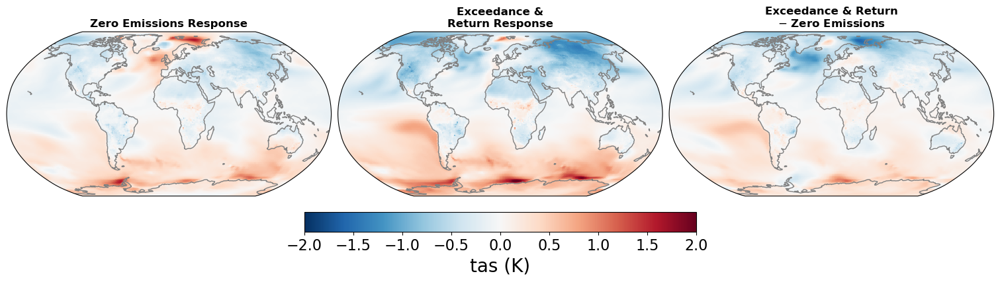

In [140]:
var='tas'
crange=2

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (' +data_in_cesm[exp_list[0]][var].units +')', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()



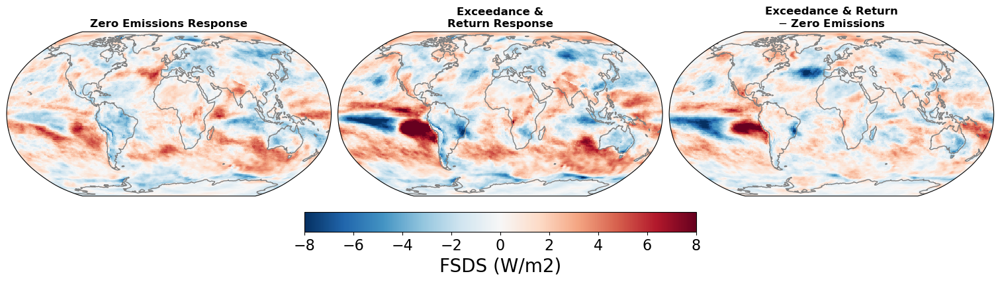

In [141]:
var='FSDS'
crange=8

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (' +data_in_cesm[exp_list[0]][var].units +')', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()


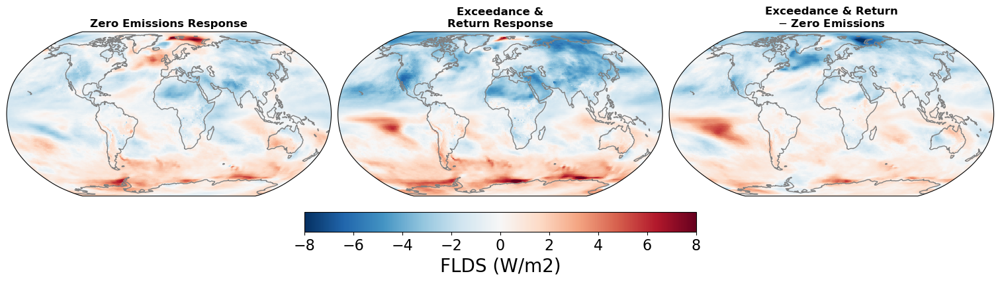

In [142]:
var='FLDS'
crange=8

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (' +data_in_cesm[exp_list[0]][var].units +')', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()


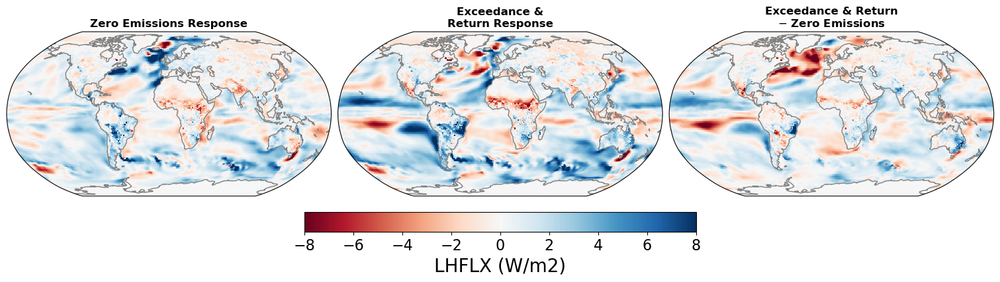

In [143]:
var='LHFLX'
crange=8

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (' +data_in_cesm[exp_list[0]][var].units +')', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()


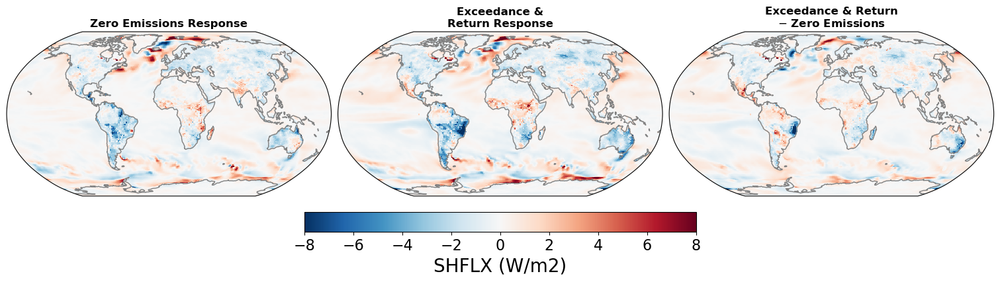

In [144]:
var='SHFLX'
crange=8

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu_r') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (' +data_in_cesm[exp_list[0]][var].units +')', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()


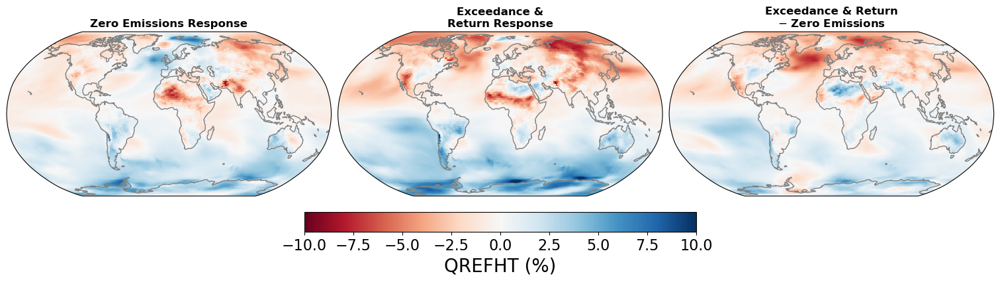

In [145]:
var='QREFHT'
# crange=.0005
crange=10

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (100*(data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var])/data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(100*(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var])/data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(100*(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var])/data_in_cesm[exp_list[0]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (%)', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()


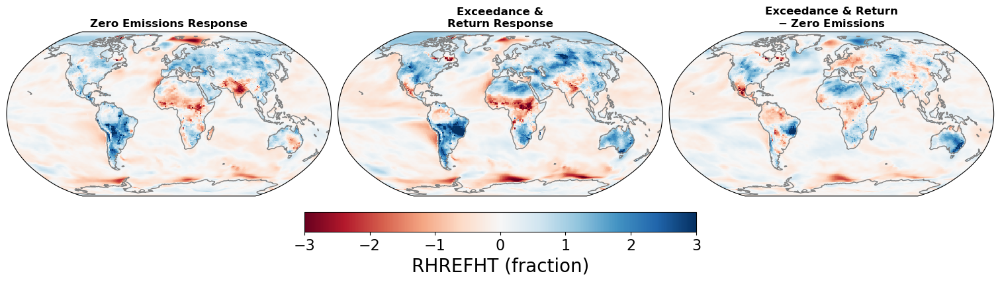

In [146]:
var='RHREFHT'
crange=3

fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

p = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')
axs[0].set_title('Zero Emissions Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')
axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[1]][var]).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False,vmax=crange,vmin=-crange,cmap='RdBu') #, levels=np.arange(40.)/10.-2.)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')
axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

### add hatching for where the change is less than on std deviation of the picontrol

# hatch1 = np.abs(data_in_cesm[1]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch1.plot.contourf(ax=axs[0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch2 = np.abs(data_in_cesm[2]-data_in_cesm[0]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch2.plot.contourf(ax=axs[1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# hatch3 = np.abs(data_in_cesm[2]-data_in_cesm[1]) < np.sqrt(variance_20year_picontrol_cesm)
# hatch3.plot.contourf(ax=axs[2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='deg C')


cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label(var +' (' +data_in_cesm[exp_list[0]][var].units +')', fontsize=20) # Large font for the label


# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6]) # [left, bottom, width, height]
# fig.colorbar(p, cbar_ax, label='Data Value')

# axs[1].set_title(var)

plt.savefig('fig_response_maps_' +var +'.png', dpi=300, bbox_inches='tight')

plt.show()


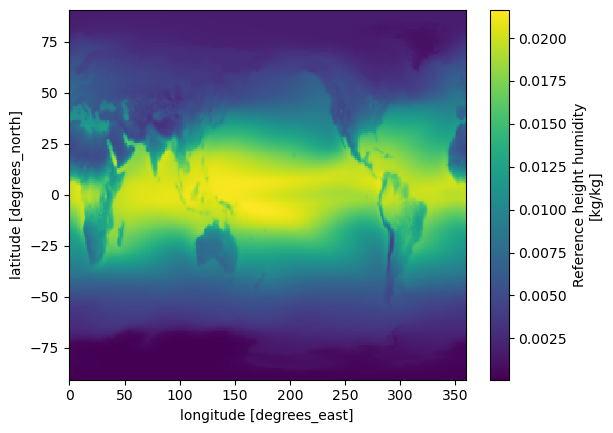

In [32]:
data_in_cesm[exp_list[1]]['QREFHT'].plot()

plt.show()

In [98]:
# landmasks_dict[model]
landmask_threshold = 0.1
nhlandmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).where(landmasks_dict[model].lat>0,0)#.values.flatten()

# nhlandmask.plot()



# nhoceanmask=(1-nhlandmask).where(landmasks_dict[model].lat>0,0)

# nhoceanmask.plot()



landmask_local = 
landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
nhlandmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).where(landmasks_dict[model].lat>0,0).values.flatten()
shlandmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).where(landmasks_dict[model].lat<0,0).values.flatten()

nhoceanmask = (1-(landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).where(landmasks_dict[model].lat>0,0)).where(landmasks_dict[model].lat>0,0).values.flatten()
shoceanmask = (1-(landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).where(landmasks_dict[model].lat<0,0)).where(landmasks_dict[model].lat<0,0).values.flatten()




np.int64(0)

In [ ]:
# fig,axs = plt.subplot(1,1)
        
# ts_in_cesm[0].plot()
# ts_in_cesm[1].plot()
# ts_in_cesm[2].plot()
# plt.show()

In [16]:


# data_dict = {
#     # 'ACCESS-ESM1-5':data_in_access,
#     'CESM2':data_in_cesm,
#     # 'CNRM-ESM2-1':data_in_cnrm,
#     # 'GFDL-ESM4':data_in_gfdl,
#     # 'GISS_E2.1':data_in_giss,
#     # 'HadCM3LC-Bris':data_in_hadcm3lc3,
#     # 'MPI-ESM1-2-LR':data_in_mpi,
#     # 'NorESM2-LM':data_in_noresm,
#     # 'UKESM1.2':data_in_ukesm,
#     # 'MIROC-ES2L':data_in_miroc
#     }

# variance_20year_picontrol_dict = {
#     # 'ACCESS-ESM1-5':variance_20year_picontrol_access,
#     'CESM2':variance_20year_picontrol_cesm,
#     # 'CNRM-ESM2-1':variance_20year_picontrol_cnrm,
#     # 'GFDL-ESM4':variance_20year_picontrol_gfdl,
#     # 'GISS_E2.1':variance_20year_picontrol_giss,
#     # 'HadCM3LC-Bris':variance_20year_picontrol_hadcm3lc3,
#     # 'MPI-ESM1-2-LR':variance_20year_picontrol_mpi,
#     # 'NorESM2-LM':variance_20year_picontrol_noresm,
#     # 'UKESM1.2':variance_20year_picontrol_ukesm,
#     # 'MIROC-ES2L':variance_20year_picontrol_miroc
#     }


In [34]:
for model_i, model in enumerate(models_list):
    print(landmasks_dict[model].max())

<xarray.DataArray 'sftlf' ()> Size: 8B
array(1.)
Attributes:
    long_name:  land fraction


In [40]:
# n_samples = 1000
# rng = np.random.default_rng()
# sampling_length = averaging_length
# quantile_to_use = .05

# lower_quantile = {}
# upper_quantile = {}

# mean_variance_dict = {}
# median_variance_dict = {}
# variance_of_variance_dict = {}
# variances_dict = {}

# for model_i, model in enumerate(models_list):
#     n_startingyears = len(picontrols_dict[model].time) - sampling_length
#     starting_indices_1 = rng.integers(low=0, high=n_startingyears, size=n_samples*2)  
#     starting_indices_2 = rng.integers(low=0, high=n_startingyears, size=n_samples*2)  
#     i_sample = 0
#     i_counter = 0
#     blank_da = xr.zeros_like(picontrols_dict[model].isel(time=0).squeeze())
#     sampled_diffs = blank_da.expand_dims(sample=n_samples)
#     print(sampled_diffs)
#     while i_sample < n_samples:
#         a = starting_indices_1[i_counter]
#         b = starting_indices_2[i_counter]
#         if abs(a - b) > sampling_length:
#             sampled_diffs[i_sample,:,:] = picontrols_dict[model].isel(time=slice(a,a+sampling_length)).mean(dim='time') - picontrols_dict[model].isel(time=slice(b,b+sampling_length)).mean(dim='time')
#             i_sample = i_sample+1
#         i_counter = i_counter + 1
#     sampled_diffs = sampled_diffs.compute()
#     lower_quantile[model] = sampled_diffs.quantile(quantile_to_use, dim='sample').squeeze()
#     upper_quantile[model] = sampled_diffs.quantile(1.-quantile_to_use, dim='sample').squeeze()
#     mean_variance_dict[model] = sampled_diffs.var(dim=['lat','lon']).mean(dim="sample").squeeze()
#     variance_of_variance_dict[model] = sampled_diffs.var(dim=['lat','lon']).var(dim="sample").squeeze()
#     median_variance_dict[model] = sampled_diffs.var(dim=['lat','lon']).median(dim="sample").squeeze()
#     variances_dict[model] = sampled_diffs.var(dim=['lat','lon'])

    

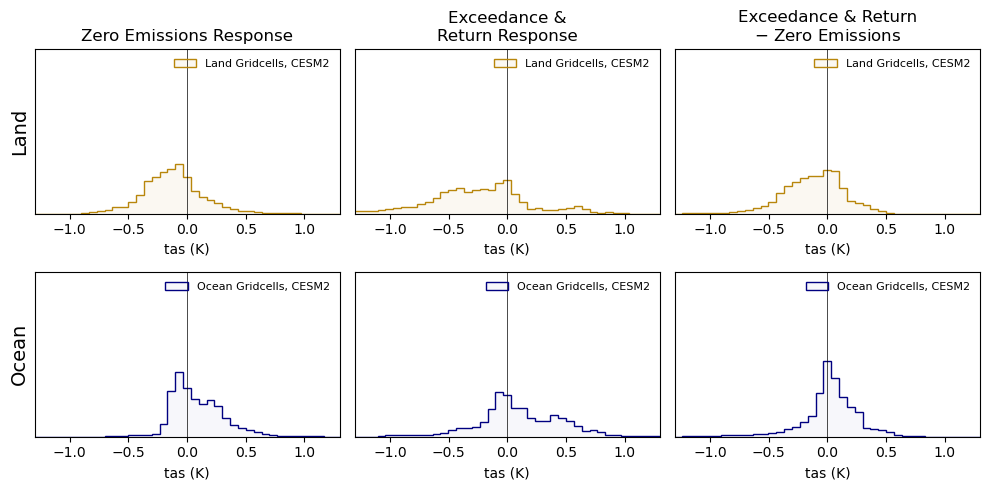

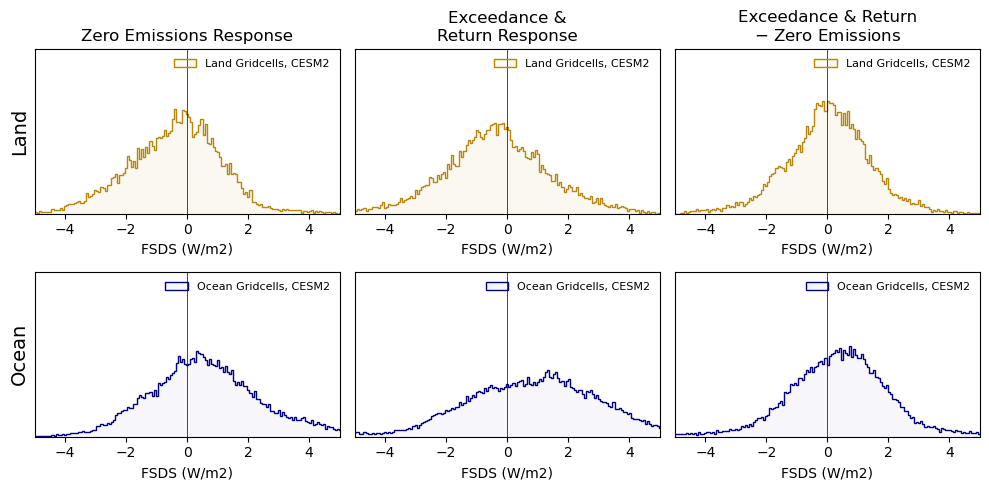

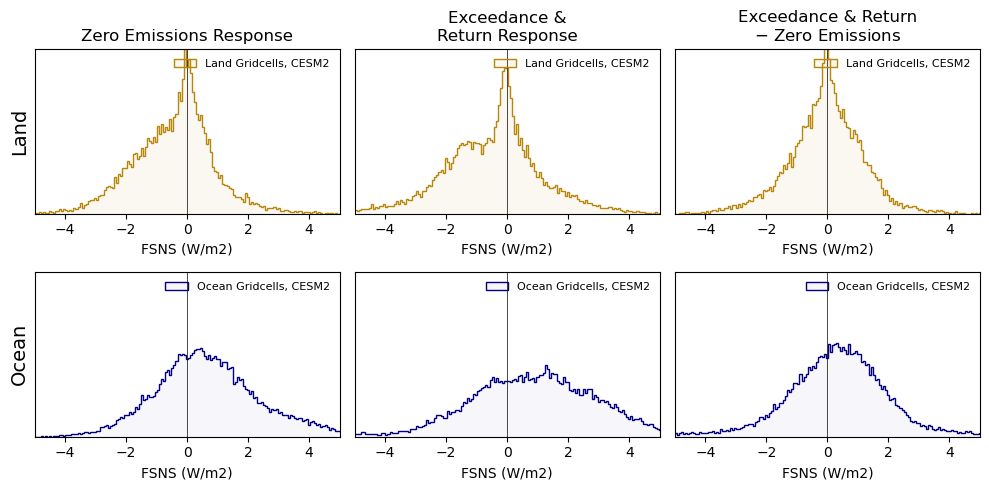

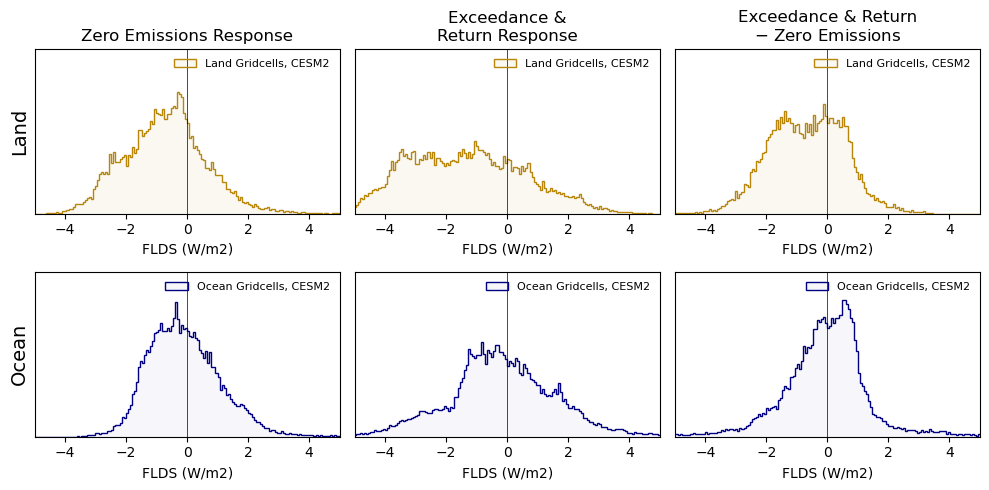

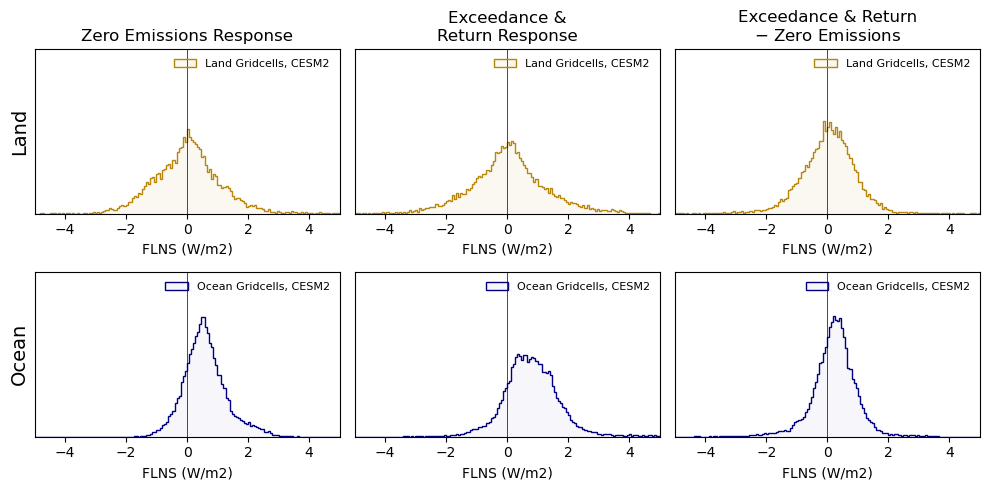

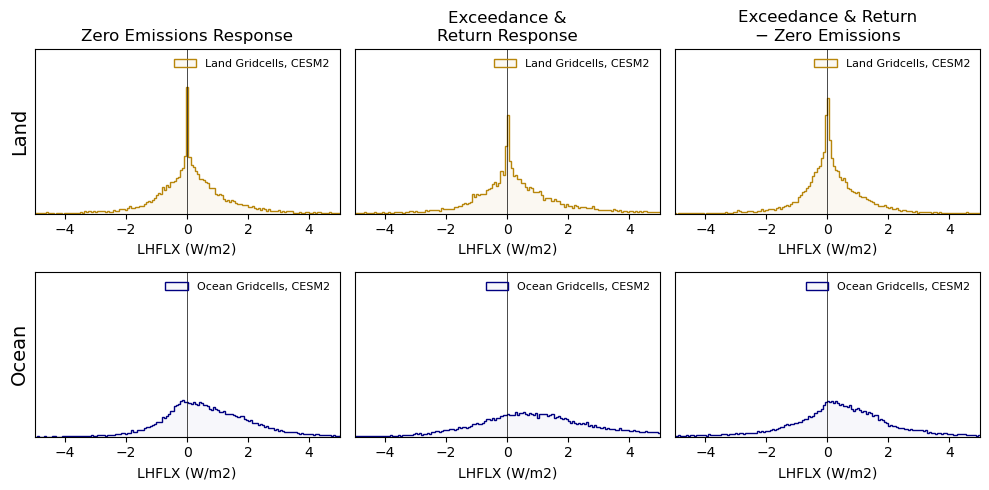

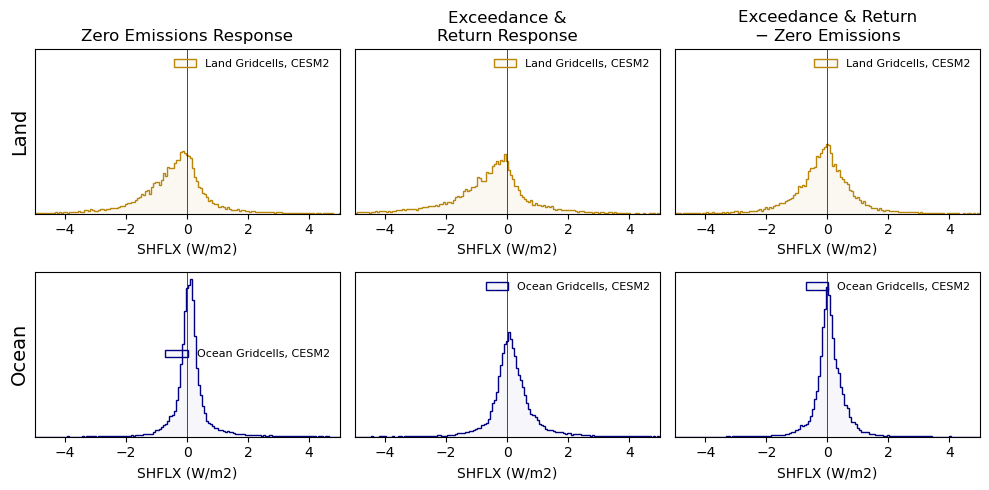

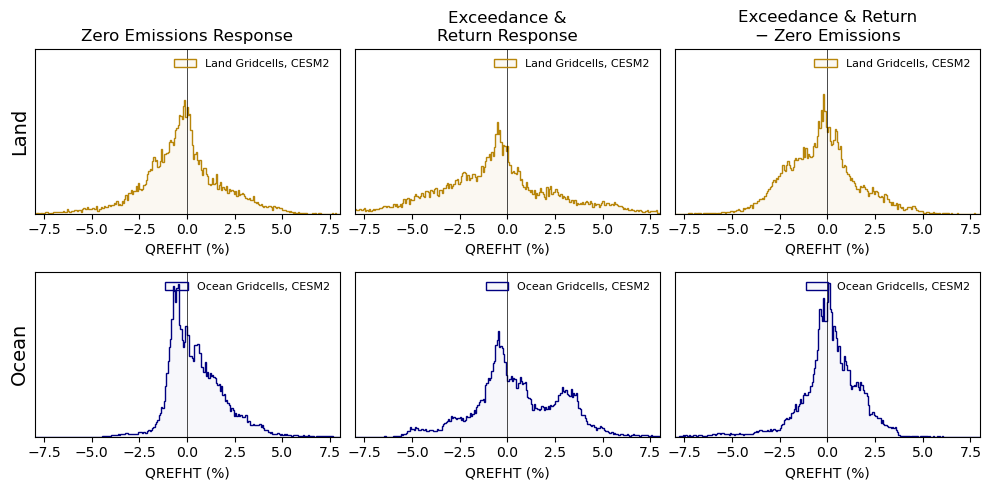

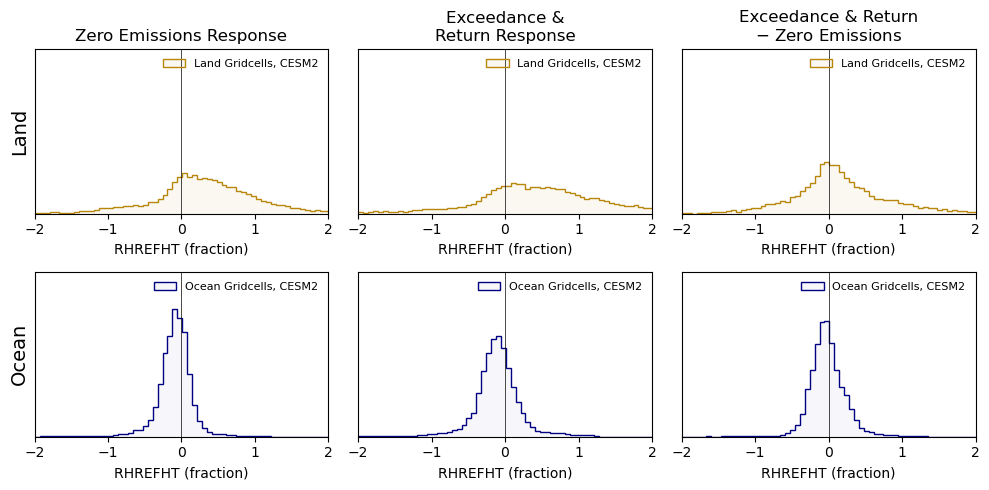

In [139]:
crange=[1.3,5,5,5,5,5,5,8,2]
yrange=[6.5,0.5,0.5,0.5,1,1.5,1.5,0.5,3]
for v in range(len(varlist)):
    var = varlist[v]
    
    fig, axs_array = plt.subplots(2, 3, figsize=(10, 5),
                           constrained_layout=True)
    
    axs = axs_array.flatten()
    
    landmask_threshold = 0.1
    
    landface = mcolors.to_rgba(landcolor, alpha=0.05)
    oceanface = mcolors.to_rgba(oceancolor, alpha=0.03)
    
    for model_i, model in enumerate(models_list):
        if model_i == 0:
            label_land = 'Land Gridcells, CESM2' #,\nIndividual Models'
            label_ocean = 'Ocean Gridcells, CESM2' #,\nIndividual Models'
        else:
            label_land = None
            label_ocean = None     
        #
        bin_edges = np.linspace(-10.,10.,300) + random.uniform(-0.1, 0.1)
        # if var=='QREFHT':
        #     bin_edges = np.linspace(-.001,.001,300) + random.uniform(-0.0001, 0.0001)
        #
        # define land mask
        landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
        #
        # data = data_dict[model]
        # data = data_in_cesm[exp_list[2]][var]
        x = (data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var]).values.flatten()
        y = (data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var]).values.flatten()

        if var=='QREFHT':
            x = (100*(data_in_cesm[exp_list[1]][var]-data_in_cesm[exp_list[0]][var])/data_in_cesm[exp_list[0]][var]).values.flatten()
            y = (100*(data_in_cesm[exp_list[2]][var]-data_in_cesm[exp_list[0]][var])/data_in_cesm[exp_list[0]][var]).values.flatten()
        #
        weights = areas_dict[model].values.flatten()
        #
        axs[0].hist(x[landmask], edgecolor=landcolor, histtype='step', density=True, bins=bin_edges, weights=weights[landmask], fill=True, facecolor=landface, label=label_land)
        #
        axs[1].hist(y[landmask], edgecolor=landcolor, histtype='step', density=True, bins=bin_edges, weights=weights[landmask], fill=True, facecolor=landface, label=label_land)
        #
        axs[2].hist((y-x)[landmask], edgecolor=landcolor, histtype='step', density=True, bins=bin_edges, weights=weights[landmask], fill=True, facecolor=landface, label=label_land)
        #
        axs[3].hist(x[~landmask], edgecolor=oceancolor, histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], fill=True, facecolor=oceanface, label=label_ocean)
        #
        axs[4].hist(y[~landmask], edgecolor=oceancolor, histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], fill=True, facecolor=oceanface, label=label_ocean)
        #
        axs[5].hist((y-x)[~landmask], edgecolor=oceancolor, histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], fill=True, facecolor=oceanface, label=label_ocean)
        #
    
    # ## ensemble mean distributions
    # x = (tas_regridded_datarray.isel(exp=1)-tas_regridded_datarray.isel(exp=0)).mean(dim='model').values.flatten()
    # y = (tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=0)).mean(dim='model').values.flatten()
         
    # landmask = (landfrac_regridded_dataarray.mean(dim='model') > landmask_threshold).values.flatten()
    # weights = (area_regridded_dataarray.mean(dim='model')).values.flatten()
    
    # bin_edges = np.linspace(-10.,10.,300)
    # axs[0].hist(x[landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[landmask], linewidth=2.5, label = 'Land Gridcells,\nEnsemble-Mean')
    # axs[1].hist(y[landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[landmask], linewidth=2.5, label = 'Land Gridcells,\nEnsemble-Mean')
    # axs[2].hist((y-x)[landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[landmask], linewidth=2.5, label = 'Land Gridcells,\nEnsemble-Mean')
    
    # axs[3].hist(x[~landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], linewidth=2.5, label = 'Ocean Gridcells,\nEnsemble-Mean')
    # axs[4].hist(y[~landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], linewidth=2.5, label = 'Ocean Gridcells,\nEnsemble-Mean')
    # axs[5].hist((y-x)[~landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], linewidth=2.5, label = 'Ocean Gridcells,\nEnsemble-Mean')
    
    panel_labels = ['Zero Emissions Response','Exceedance &\nReturn Response','Exceedance & Return\n$\minus$ Zero Emissions']
    for ax_x in range(len(axs)):
        axs[ax_x].vlines(0, ymin=0,ymax=1, transform=axs[ax_x].get_xaxis_transform(), color='black', linewidth=0.5)
        #
        axs[ax_x].set_xlim(-crange[v],crange[v])#-1.3,1.3)
        axs[ax_x].set_ylim(0,yrange[v])
        #
        # axs[ax_x].set_xlabel(var)#'Temperature Difference (°C)')
        axs[ax_x].set_xlabel(var +' (' +data_in_cesm[exp_list[0]][var].units +')')#'Temperature Difference (°C)')
        if var == 'QREFHT':
            axs[ax_x].set_xlabel(var +' (%)')#'Temperature Difference (°C)')
        axs[ax_x].tick_params(axis='y', left=False, labelleft=False)
        #
        if ax_x < 3:
            axs[ax_x].set_title(panel_labels[ax_x])
        if ax_x == 0:
            axs[ax_x].set_ylabel('Land', fontsize=14)
        if ax_x == 3:
            axs[ax_x].set_ylabel('Ocean', fontsize=14)
        axs[ax_x].legend(fontsize=8, frameon=False)
    
        
    plt.tight_layout()
    
    plt.savefig('fig_temp_response_landocean_histograms_' +var +'.png', dpi=300, bbox_inches='tight')
    


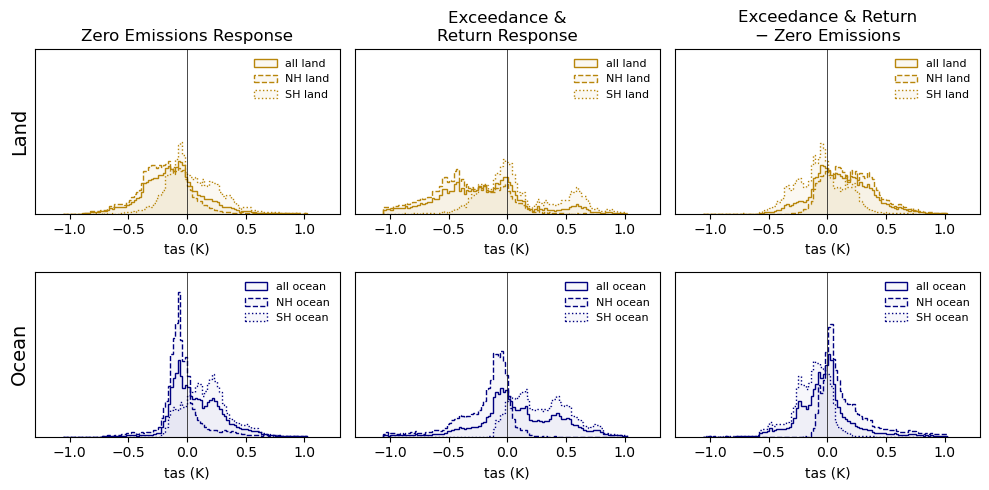

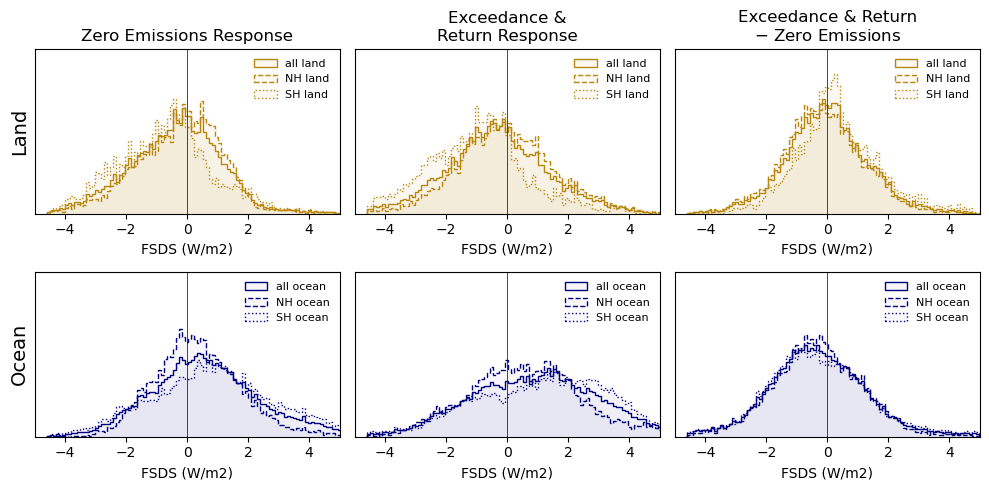

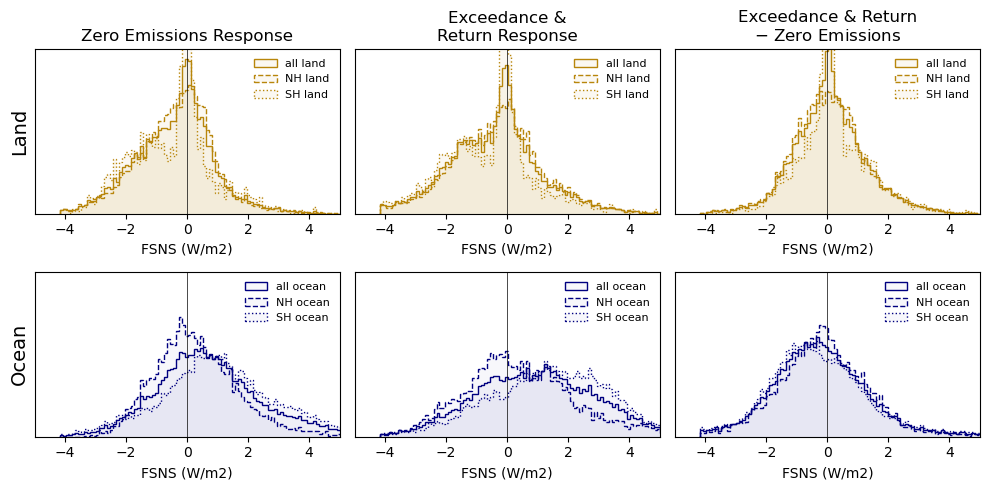

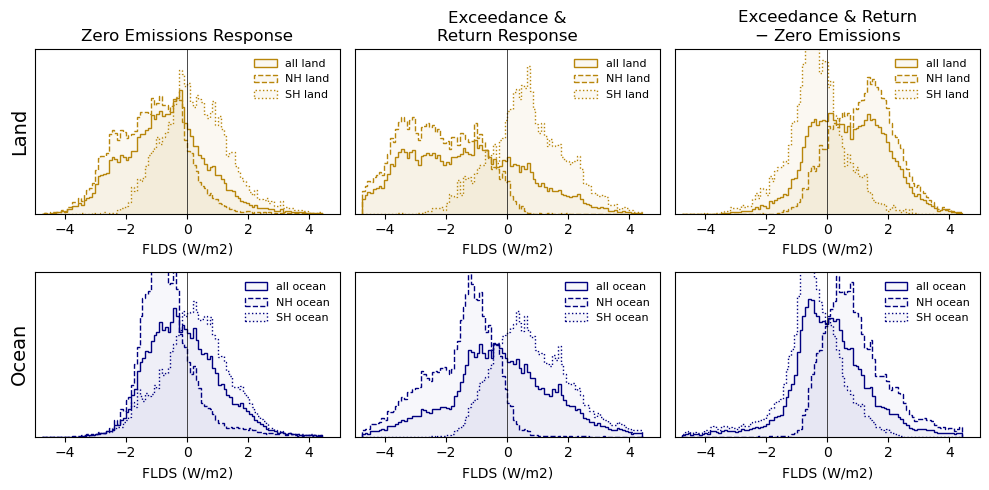

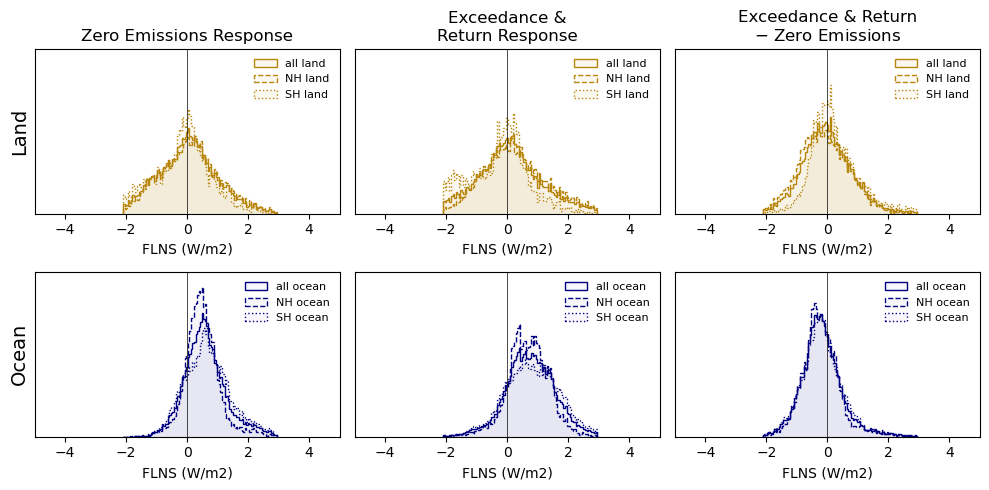

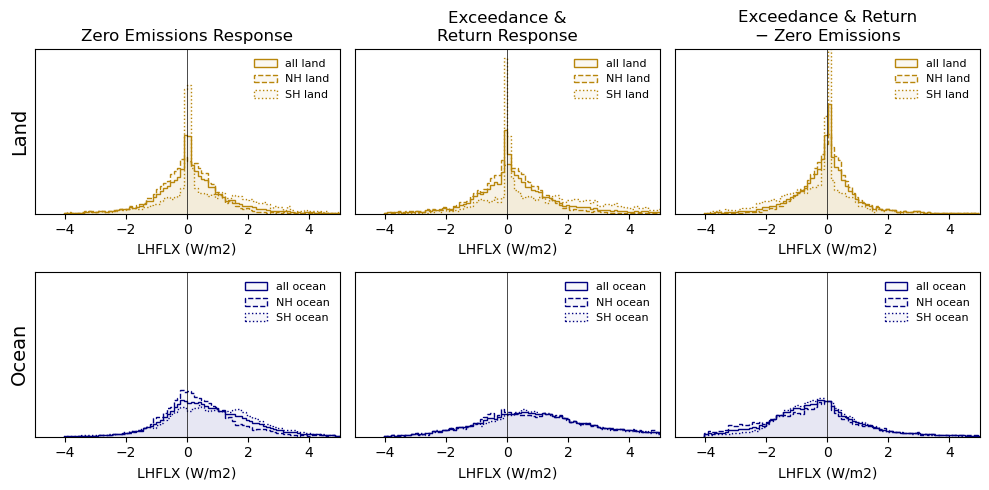

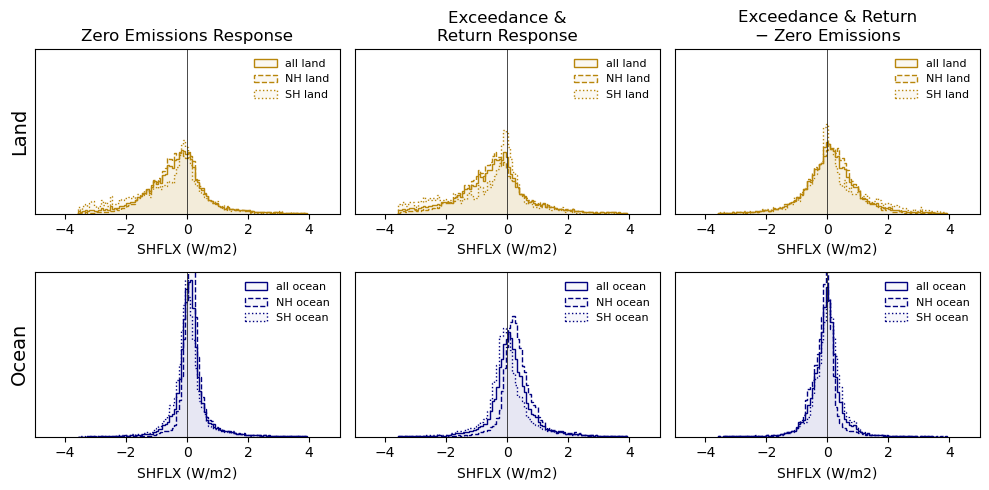

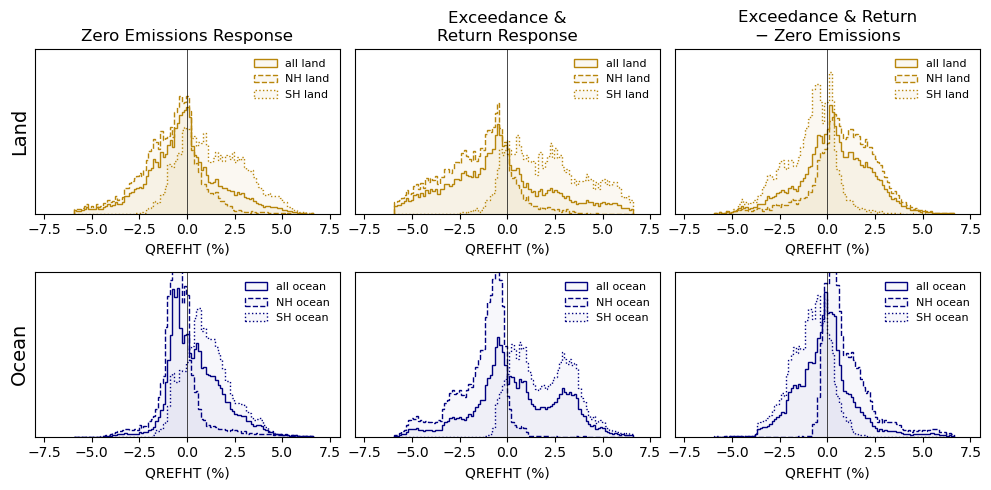

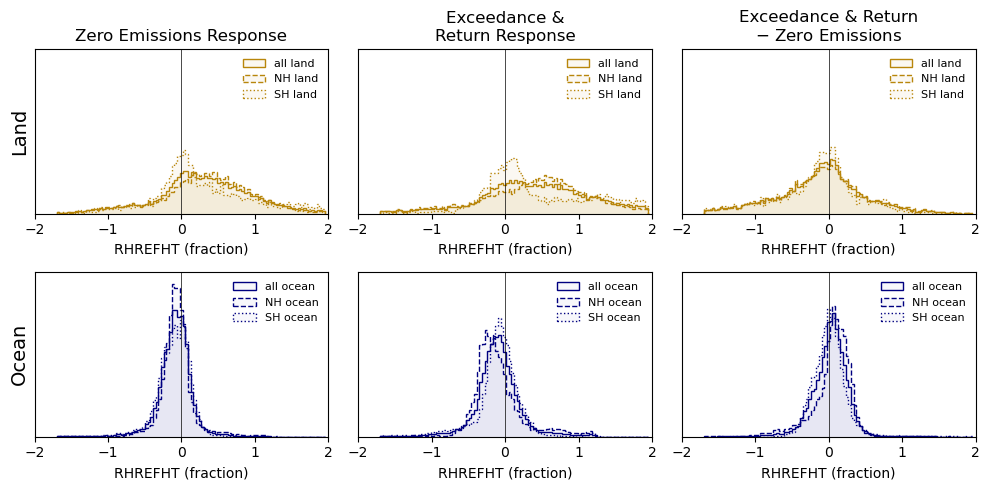

In [138]:
crange=[1.3,5,5,5,5,5,5,8,2]
yrange=[6.5,0.5,0.5,0.5,1,1.5,1.5,0.5,3]
for v in range(len(varlist)):
    var = varlist[v]
    
    fig, axs_array = plt.subplots(2, 3, figsize=(10, 5),
                           constrained_layout=True)
    
    axs = axs_array.flatten()
    
    landmask_threshold = 0.1
    
    landface = mcolors.to_rgba(landcolor, alpha=0.05)
    oceanface = mcolors.to_rgba(oceancolor, alpha=0.03)
    
    for model_i, model in enumerate(models_list):
        if model_i == 0:
            label_land = 'Land Gridcells, CESM2' #,\nIndividual Models'
            label_ocean = 'Ocean Gridcells, CESM2' #,\nIndividual Models'
        else:
            label_land = None
            label_ocean = None     
        #
        # bin_edges = np.linspace(-10.,10.,300) + random.uniform(-0.1, 0.1)
        # if var=='QREFHT':
        #     bin_edges = np.linspace(-.001,.001,300) + random.uniform(-0.0001, 0.0001)
        #

        
        thresh = landmask_threshold * landmask_local.max().values
        lm = landmask_local.values
        lat2d = np.broadcast_to(landmask_local.lat.values[:, None], lm.shape)
        
        land  = lm > thresh
        ocean = ~land
        #ocean = lm <= thresh
        nh = lat2d > 0
        sh = lat2d < 0
        
        x = (data_in_cesm[exp_list[1]][var] - data_in_cesm[exp_list[0]][var]).values
        y = (data_in_cesm[exp_list[2]][var] - data_in_cesm[exp_list[0]][var]).values

        if var == 'QREFHT':
            x = (100*(data_in_cesm[exp_list[1]][var] - data_in_cesm[exp_list[0]][var])/data_in_cesm[exp_list[0]][var]).values
            y = (100*(data_in_cesm[exp_list[2]][var] - data_in_cesm[exp_list[0]][var])/data_in_cesm[exp_list[0]][var]).values
        
        xmy = x-y
        a = np.broadcast_to(area.values, x.shape)    # gridbox area, (lat, lon)
        
        valid   = np.isfinite(x) & (np.abs(x) < 1e30) & np.isfinite(a)
        valid_y = np.isfinite(y) & (np.abs(y) < 1e30) & np.isfinite(a)
        valid_xmy = np.isfinite(xmy) & (np.abs(xmy) < 1e30) & np.isfinite(a)
        
        # common bins from the 1st-99th percentile of x and y combined
        pooled = np.concatenate([x[valid], y[valid_y]])
        lo, hi = np.percentile(pooled, [1, 99])
        bins = np.linspace(lo, hi, 101)
        
        ## zec
        # Land
        sel = valid & np.broadcast_to(land, x.shape)
        axs[0].hist(x[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='all land')

        # NH Land
        sel = valid & np.broadcast_to(land & nh, x.shape)
        axs[0].hist(x[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='NH land',linestyle='--')
        
        # SH Land
        sel = valid & np.broadcast_to(land & sh, x.shape)
        axs[0].hist(x[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='SH land',linestyle=':')


        ## cdr
        # Land
        sel = valid_y & np.broadcast_to(land, x.shape)
        axs[1].hist(y[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='all land')

        # NH Land
        sel = valid_y & np.broadcast_to(land & nh, x.shape)
        axs[1].hist(y[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='NH land',linestyle='--')
        
        # SH Land
        sel = valid_y & np.broadcast_to(land & sh, x.shape)
        axs[1].hist(y[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='SH land',linestyle=':')


        ## difference
        # Land
        sel = valid_xmy & np.broadcast_to(land, x.shape)
        axs[2].hist(xmy[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='all land')

        # NH Land
        sel = valid & np.broadcast_to(land & nh, x.shape)
        axs[2].hist(xmy[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='NH land',linestyle='--')
        
        # SH Land
        sel = valid & np.broadcast_to(land & sh, x.shape)
        axs[2].hist(xmy[sel], bins=bins, weights=a[sel], density=True, edgecolor=landcolor, histtype='step', fill=True, facecolor=landface, label='SH land',linestyle=':')




        ## zec
        # Ocean
        sel = valid & np.broadcast_to(ocean, x.shape)
        axs[3].hist(x[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='all ocean')
        
        # NH Ocean
        sel = valid & np.broadcast_to(ocean & nh, x.shape)
        axs[3].hist(x[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='NH ocean',linestyle='--')
        
        # SH Ocean
        sel = valid & np.broadcast_to(ocean & sh, x.shape)
        axs[3].hist(x[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='SH ocean',linestyle=':')

        ## cdr
        # Ocean
        sel = valid_y & np.broadcast_to(ocean, x.shape)
        axs[4].hist(y[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='all ocean')
        
        # NH Ocean
        sel = valid_y & np.broadcast_to(ocean & nh, x.shape)
        axs[4].hist(y[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='NH ocean',linestyle='--')
        
        # SH Ocean
        sel = valid_y & np.broadcast_to(ocean & sh, x.shape)
        axs[4].hist(y[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='SH ocean',linestyle=':')
        
        ## difference
        # Ocean
        sel = valid_xmy & np.broadcast_to(ocean, x.shape)
        axs[5].hist(xmy[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='all ocean')
        
        # NH Ocean
        sel = valid_xmy & np.broadcast_to(ocean & nh, x.shape)
        axs[5].hist(xmy[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='NH ocean',linestyle='--')
        
        # SH Ocean
        sel = valid_xmy & np.broadcast_to(ocean & sh, x.shape)
        axs[5].hist(xmy[sel], bins=bins, weights=a[sel], density=True, edgecolor=oceancolor, histtype='step', fill=True, facecolor=oceanface, label='SH ocean',linestyle=':')

    
    panel_labels = ['Zero Emissions Response','Exceedance &\nReturn Response','Exceedance & Return\n$\minus$ Zero Emissions']
    for ax_x in range(len(axs)):
        axs[ax_x].vlines(0, ymin=0,ymax=1, transform=axs[ax_x].get_xaxis_transform(), color='black', linewidth=0.5)
        #
        axs[ax_x].set_xlim(-crange[v],crange[v])#-1.3,1.3)
        axs[ax_x].set_ylim(0,yrange[v])
        #
        axs[ax_x].set_xlabel(var +' (' +data_in_cesm[exp_list[0]][var].units +')')#'Temperature Difference (°C)')
        if var == 'QREFHT':
            axs[ax_x].set_xlabel(var +' (%)')#'Temperature Difference (°C)')
        axs[ax_x].tick_params(axis='y', left=False, labelleft=False)
        #
        if ax_x < 3:
            axs[ax_x].set_title(panel_labels[ax_x])
        if ax_x == 0:
            axs[ax_x].set_ylabel('Land', fontsize=14)
        if ax_x == 3:
            axs[ax_x].set_ylabel('Ocean', fontsize=14)
        axs[ax_x].legend(fontsize=8, frameon=False)
    
        
    plt.tight_layout()
    
    plt.savefig('fig_temp_response_landocean_hemisphere_histograms_' +var +'.png', dpi=300, bbox_inches='tight')
    


In [135]:
data_in_cesm[exp_list[0]][var].units

'fraction'

In [36]:
mean_variance_dict

NameError: name 'mean_variance_dict' is not defined

In [20]:
variance_of_variance_dict

{'ACCESS-ESM1-5': <xarray.DataArray ()>
 array(0.00163773)
 Coordinates:
     time     object 0271-12-16 12:00:00
     height   float64 2.0,
 'CESM2': <xarray.DataArray ()>
 array(0.00113526)
 Coordinates:
     time     object 0001-12-15 12:00:00,
 'CNRM-ESM2-1': <xarray.DataArray ()>
 array(0.10302134)
 Coordinates:
     height   float64 2.0
     time     object 1850-12-16 12:00:00,
 'GFDL-ESM4': <xarray.DataArray ()>
 array(0.01343956)
 Coordinates:
     height   float64 2.0
     time     object 0001-12-16 12:00:00,
 'GISS_E2.1': <xarray.DataArray ()>
 array(0.00071721)
 Coordinates:
     time     object 1850-12-16 12:00:00
     height   float64 2.0,
 'HadCM3LC-Bris': <xarray.DataArray 'temp_mm_1_5m' ()>
 array(0.00084853)
 Coordinates:
     time     object 1651-07-02 00:00:00
     ht       float32 -1.0
     year     int64 1651,
 'MPI-ESM1-2-LR': <xarray.DataArray ()>
 array(0.00206346)
 Coordinates:
     time     object 0001-12-16 12:00:00
     height   float64 2.0,
 'NorESM2-LM': <

HDF5-DIAG: Error detected in HDF5 (1.12.2) thread 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object not 

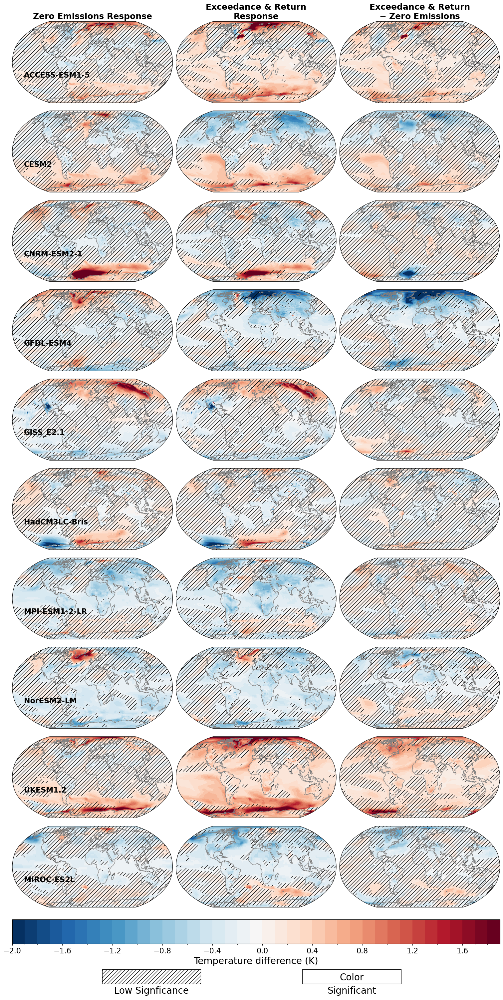

In [21]:
fig, axs = plt.subplots(nmodels+1, 3, figsize=(15, 30),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)
p
for model_i, model in enumerate(models_list):
    data = data_dict[model]
    variance_20year_picontrol = variance_20year_picontrol_dict[model]
    #
    p = (data[1]-data[0]).plot(ax=axs[model_i,0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
    axs[model_i,0].add_feature(feature.COASTLINE, edgecolor='grey')
    #
    (data[2]-data[0]).plot(ax=axs[model_i,1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
    axs[model_i,1].add_feature(feature.COASTLINE, edgecolor='grey')
    #
    (data[2]-data[1]).plot(ax=axs[model_i,2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=np.arange(40.)/10.-2.)
    axs[model_i,2].add_feature(feature.COASTLINE, edgecolor='grey')
    #
    #
    ### add hatching for where the change is less than on std deviation of the picontrol
    hatch1 = 1.-(((data[1]-data[0]) < lower_quantile[model]) + ((data[1]-data[0]) > upper_quantile[model]))
    wrap_hatch1, wrap_lons = add_cyclic_point(hatch1, coord=hatch1.lon.as_numpy())
    wrap_hatch1_dataarray = xr.DataArray(wrap_hatch1, 
            coords={"lat": hatch1.lat, "lon": wrap_lons}, dims=("lat", "lon"))
    wrap_hatch1_dataarray.plot.contourf(ax=axs[model_i,0], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))
    #
    hatch2 = 1.-(((data[2]-data[0]) < lower_quantile[model]) + ((data[2]-data[0]) > upper_quantile[model]))
    wrap_hatch2, wrap_lons = add_cyclic_point(hatch2, coord=hatch2.lon.as_numpy())
    wrap_hatch2_dataarray = xr.DataArray(wrap_hatch2, 
            coords={"lat": hatch2.lat, "lon": wrap_lons}, dims=("lat", "lon"))
    wrap_hatch2_dataarray.plot.contourf(ax=axs[model_i,1], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))
    #
    hatch3 = 1.-(((data[2]-data[1]) < lower_quantile[model]) + ((data[2]-data[1]) > upper_quantile[model]))
    wrap_hatch3, wrap_lons = add_cyclic_point(hatch3, coord=hatch3.lon.as_numpy())
    wrap_hatch3_dataarray = xr.DataArray(wrap_hatch3, 
            coords={"lat": hatch1.lat, "lon": wrap_lons}, dims=("lat", "lon"))
    wrap_hatch3_dataarray.plot.contourf(ax=axs[model_i,2], transform=ccrs.PlateCarree(), colors='none', add_colorbar=False, levels=[0.5,1.5], hatches=('','///'))


# 3. Label the columns (set titles for the top row)
column_labels = ['Zero Emissions Response', 'Exceedance & Return\nResponse', 'Exceedance & Return\n$\minus$ Zero Emissions']
for ax, col in zip(axs[0, :], column_labels):
    ax.set_title(col, size=18, fontweight='bold')

for i in range(2,nmodels):
    for ax, col in zip(axs[i, :], column_labels):
        ax.set_title('')

# 4. Label the rows (set y-labels for the first column)
row_labels = models_list
for ax, row in zip(axs[:, 0], row_labels):
    ax.text(200., -30., row, transform=ccrs.Geodetic(), size=16, fontweight='bold')
    

axs[nmodels, 0].axis('off')
axs[nmodels, 1].axis('off')
axs[nmodels, 2].axis('off')

cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.04, pad=-0.077, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label('Temperature difference (K)', fontsize=20) # Large font for the label


ax6 = fig.add_subplot(70,5,347)
ax6.contourf([0,1,2],[0,1,2],np.ones((3,3))*1.,levels=[0.5,2],
             colors='none',
             hatches=['///'], 
             alpha=0.00)
ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
ax6.text(1,-1,'Low Signficance', verticalalignment='center', horizontalalignment='center', fontsize=20)

ax7 = fig.add_subplot(70,5,349)
ax7.contourf([0,1,2],[0,1,2],np.ones((3,3))*0.,levels=[0.5,2],
             colors='none',
             hatches=['///'], 
             alpha=0.00)
ax7.xaxis.set_visible(False)
ax7.yaxis.set_visible(False)
ax7.text(1,-1,'Significant', verticalalignment='center', horizontalalignment='center', fontsize=20)
ax7.text(1,0.9,'Color', verticalalignment='center', horizontalalignment='center', fontsize=20)

#plt.tight_layout()

plt.savefig('fig_temp_response_maps_bymodel.png', dpi=150, bbox_inches='tight')


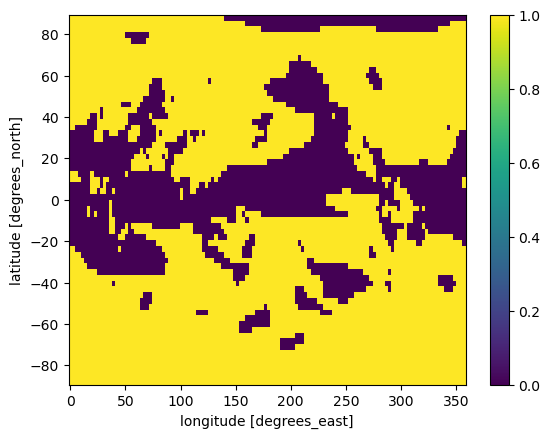

In [22]:
hatch1.plot()

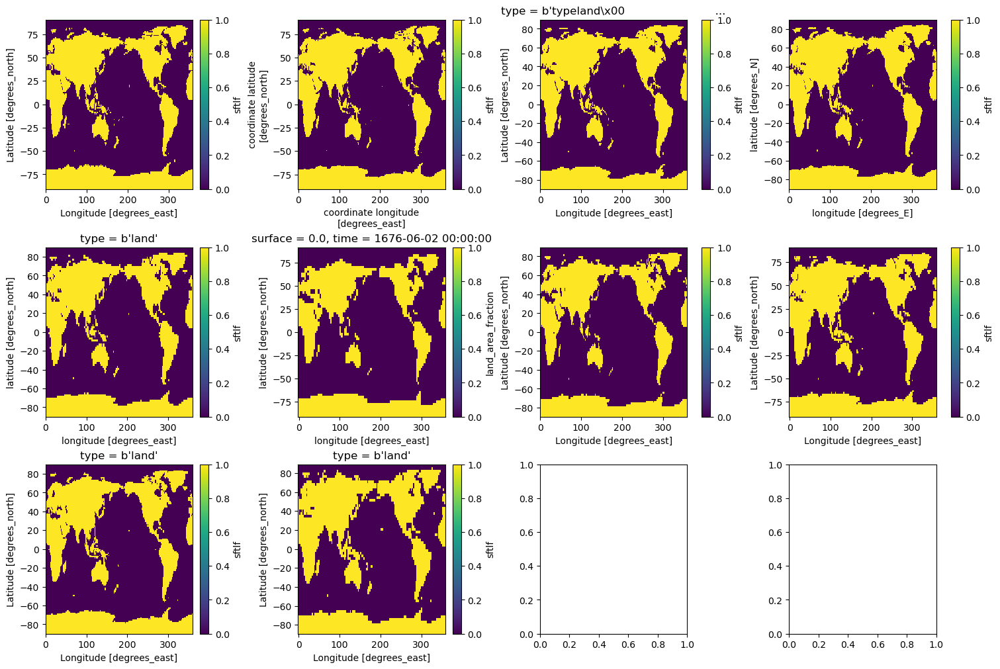

In [23]:

fig, axs = plt.subplots(3, 4, figsize=(15, 10),
                       constrained_layout=True)
axs_flat = axs.flatten()

for model_i, model in enumerate(models_list):
    #
    # define land mask
    (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).plot(ax = axs_flat[model_i])


/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_2568/3650934587.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


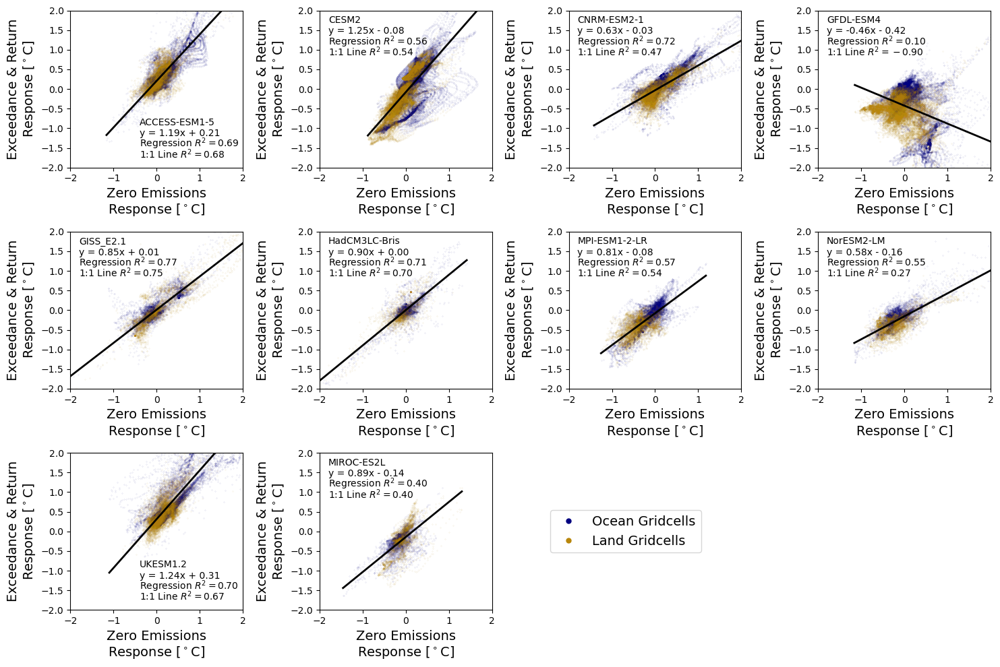

In [24]:
fig, axs = plt.subplots(3, 4, figsize=(15, 10),
                       constrained_layout=True)
axs_flat = axs.flatten()

slopes = []
regression_r2s = []
onetoone_r2s = []
variance_cdr_response = {}
variance_zec_response = {}
variance_unshared = {}

corner_offset = [1,0,0,0,0,0,0,0,1,0]
xoffset = 0.35
yoffset = -0.65


landcolor = 'darkgoldenrod'
oceancolor = 'navy'

for model_i, model in enumerate(models_list):
    #
    # define land mask
    landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
    #
    data = data_dict[model]
    x = (data[1]-data[0]).values.flatten()
    y = (data[2]-data[0]).values.flatten()
    #
    axs_flat[model_i].plot(x[~landmask], y[~landmask], '.', c=oceancolor, ms=0.2, alpha=0.5)
    axs_flat[model_i].plot(x[landmask], y[landmask], '.', c=landcolor, ms=0.2, alpha=0.5)
    #
    b, a = np.polyfit(x, y, deg=1)
    slopes.append(b)
    xseq = np.linspace(x.min(), x.max(), num=100)
    axs_flat[model_i].plot(xseq, a + b * xseq, color="k", lw=2)
    annotation_text_regress = f"y = {b:.2f}x {'+' if a >= 0 else '-'} {abs(a):.2f}"
    axs_flat[model_i].annotate(annotation_text_regress, xy=(corner_offset[model_i]*xoffset+0.05, corner_offset[model_i]*yoffset+0.85), xycoords='axes fraction', fontsize=10)
    #
    y_pred = a + b * x
    r2 = 1 - np.var(y_pred-y) / np.var(y)
    regression_r2s.append(r2)
    annotation_text_rsq = f"Regression $R^2 = {r2:.2f}$"
    axs_flat[model_i].annotate(annotation_text_rsq, xy=(corner_offset[model_i]*xoffset+0.05, corner_offset[model_i]*yoffset+0.78), xycoords='axes fraction', fontsize=10)
    #
    r2_1to1 = 1 - np.var(y-x) / np.var(y)
    onetoone_r2s.append(r2_1to1)
    annotation_text_rsq = f"1:1 Line $R^2 = {r2_1to1:.2f}$"
    axs_flat[model_i].annotate(annotation_text_rsq, xy=(corner_offset[model_i]*xoffset+0.05, corner_offset[model_i]*yoffset+0.71), xycoords='axes fraction', fontsize=10)
    #
    variance_cdr_response[model] = np.var(y)
    variance_unshared[model] = np.var(y-x)
    variance_zec_response[model] = np.var(x)
    #
    axs_flat[model_i].set_xlim(-2,2)
    axs_flat[model_i].set_ylim(-2,2)
    axs_flat[model_i].set_xlabel('Zero Emissions\nResponse [$^\circ$C]', size=14)
    axs_flat[model_i].set_ylabel('Exceedance & Return\nResponse [$^\circ$C]', size=14)
    #
    axs_flat[model_i].annotate(model, xy=(corner_offset[model_i]*xoffset+0.05, corner_offset[model_i]*yoffset+0.92), xycoords='axes fraction', fontsize=10)
    #
    if model_i == len(models_list)-1:
        axs_flat[model_i].plot([None],[None], '.', c=oceancolor, ms=10, label='Ocean Gridcells')
        axs_flat[model_i].plot([None],[None], '.', c=landcolor, ms=10, label='Land Gridcells')
        legend = axs_flat[model_i].legend(loc='center left', bbox_to_anchor=(1.3, 0.5), fontsize=14)
        legend.set_in_layout(False)

    
plt.tight_layout()

axs_flat[10].axis('off')
axs_flat[11].axis('off')

plt.savefig('fig_temp_response_scatterplots.png', dpi=300, bbox_inches='tight')


In [25]:
print(np.median(slopes))
print(np.median(regression_r2s))
print(np.median(onetoone_r2s))

0.8692346399215269
0.630332887172699
0.5387573391199112


In [26]:
onetoone_r2s

[0.67535001039505,
 0.5395528674125671,
 0.4729917049407959,
 -0.9035940170288086,
 0.7484464347362518,
 0.6997330486774445,
 0.5379618108272552,
 0.2716497778892517,
 0.6723253726959229,
 0.3964829444885254]

In [27]:
shared_fraction_variance = []
unforced_fraction_variance = []
remaining_fraction_variance = []
for model_i, model in enumerate(models_list):
    shared_fraction_variance.append(1.-variance_unshared[model]/variance_cdr_response[model])
    unforced_fraction_variance.append((median_variance_dict[model]/variance_cdr_response[model]).data)


In [28]:
np.array(shared_fraction_variance)

array([ 0.67535001,  0.53955287,  0.4729917 , -0.90359402,  0.74844643,
        0.69973305,  0.53796181,  0.27164978,  0.67232537,  0.39648294])

In [29]:
np.array(unforced_fraction_variance)

array([0.36907341, 0.23234595, 1.93836243, 0.58626404, 0.30396101,
       0.3887394 , 0.74071761, 0.62267235, 0.2737067 , 0.54983737])

In [30]:
1. - (np.array(shared_fraction_variance) + np.array(unforced_fraction_variance))

array([-0.04442342,  0.22810118, -1.41135413,  1.31732998, -0.05240745,
       -0.08847245, -0.27867942,  0.10567787,  0.05396792,  0.05367968])

In [31]:
areas_dict

{'CESM2': <xarray.DataArray 'areacella' (lat: 192, lon: 288)>
 array([[2.994837e+07, 2.994837e+07, 2.994837e+07, ..., 2.994837e+07,
         2.994837e+07, 2.994837e+07],
        [2.395748e+08, 2.395748e+08, 2.395748e+08, ..., 2.395748e+08,
         2.395748e+08, 2.395748e+08],
        [4.790848e+08, 4.790848e+08, 4.790848e+08, ..., 4.790848e+08,
         4.790848e+08, 4.790848e+08],
        ...,
        [4.790848e+08, 4.790848e+08, 4.790848e+08, ..., 4.790848e+08,
         4.790848e+08, 4.790848e+08],
        [2.395748e+08, 2.395748e+08, 2.395748e+08, ..., 2.395748e+08,
         2.395748e+08, 2.395748e+08],
        [2.994837e+07, 2.994837e+07, 2.994837e+07, ..., 2.994837e+07,
         2.994837e+07, 2.994837e+07]], dtype=float32)
 Coordinates:
   * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
   * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
     time     object 0001-02-01 00:00:00
 Attributes:
     units:         m2
     long_

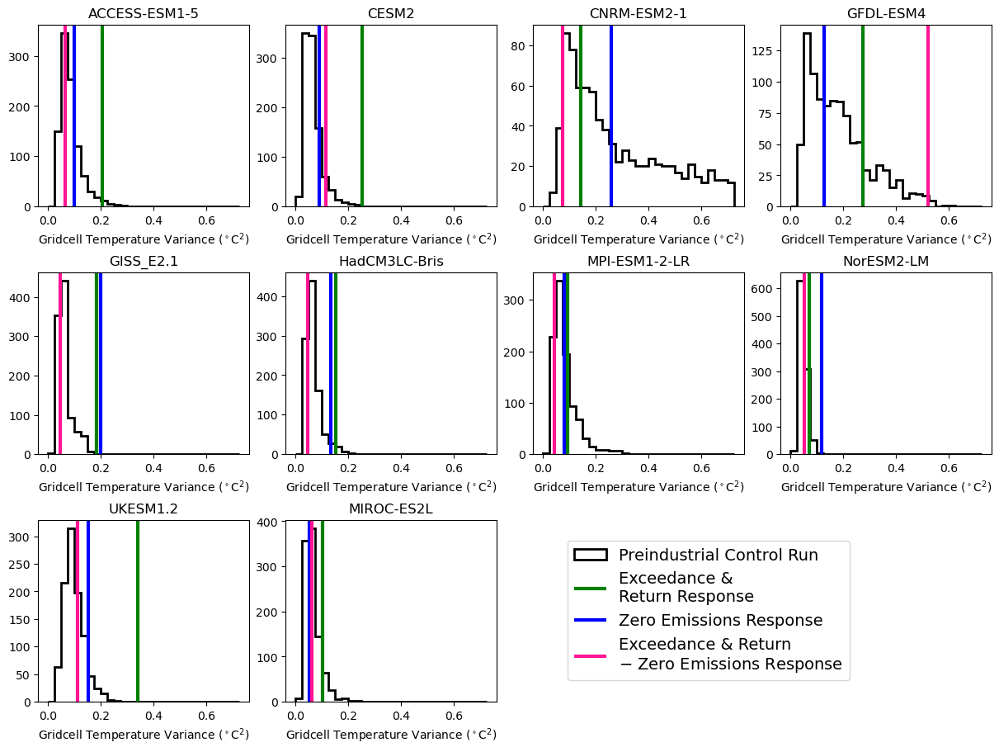

In [32]:
fig, axs = plt.subplots(3,4, figsize=(12, 9),
                       constrained_layout=True)
axs_flat = axs.flatten()
                        
for model_i, model in enumerate(models_list):
    variances_dict[model].plot.hist(histtype='step', label='Preindustrial Control Run', bins=np.arange(30)/40., ax=axs_flat[model_i], lw=2, color='black')
    #plt.vlines(variance_cdr_response[model], ymin=100,ymax=500)
    axs_flat[model_i].vlines(variance_cdr_response[model], ymin=0,ymax=1, transform=axs_flat[model_i].get_xaxis_transform(), label='Exceedance &\nReturn Response', color='Green', lw=3)
    axs_flat[model_i].vlines(variance_zec_response[model], ymin=0,ymax=1, transform=axs_flat[model_i].get_xaxis_transform(), label='Zero Emissions Response', color='Blue', lw=3)
    axs_flat[model_i].vlines(variance_unshared[model], ymin=0,ymax=1, transform=axs_flat[model_i].get_xaxis_transform(), label='Exceedance & Return\n$\minus$ Zero Emissions Response', color='deeppink', lw=3)
    axs_flat[model_i].set_title(model)
    if model_i == len(models_list)-1:
        legend = axs_flat[model_i].legend(loc='center left', bbox_to_anchor=(1.3, 0.5), fontsize=14)
        legend.set_in_layout(False)
    axs_flat[model_i].set_xlabel('Gridcell Temperature Variance ($^\circ$C$^2$)')
    
axs_flat[10].axis('off')
axs_flat[11].axis('off')

plt.savefig('fig_temp_response_histograms.png', dpi=300, bbox_inches='tight')


In [33]:
ds_out = xe.util.grid_global(1, 1) # 1d resolution

tas_regridded_datarray = xr.DataArray(
    np.zeros([180,360,3,nmodels])/np.zeros([180,360,3,nmodels]),
    coords={"lat": np.arange(180)-89.5, "lon": np.arange(360)-179.5, "exp":np.arange(3), "model": np.arange(nmodels)},
    dims=("lat", "lon", "exp", "model"),
    name='tas',
    attrs=dict(
        description="Surface Air Temperature",
        units="K",
    ))

landfrac_regridded_dataarray = xr.DataArray(
    np.zeros([180,360,nmodels])/np.zeros([180,360,nmodels]),
    coords={"lat": np.arange(180)-89.5, "lon": np.arange(360)-179.5, "model": np.arange(nmodels)},
    dims=("lat", "lon", "model"),
    name='landfrac',
    attrs=dict(
        description="Land Fraction",
        units="unitless",
    ))

area_regridded_dataarray = xr.DataArray(
    np.zeros([180,360,nmodels])/np.zeros([180,360,nmodels]),
    coords={"lat": np.arange(180)-89.5, "lon": np.arange(360)-179.5, "model": np.arange(nmodels)},
    dims=("lat", "lon", "model"),
    name='area',
    attrs=dict(
        description="area",
        units="m2",
    ))

# Create a dictionary of desired renames { 'old_name': 'new_name' }
rename_dict = {"longitude":"lon","latitude":"lat"}

for model_i, model in enumerate(models_list):
    # Filter the dictionary to only include variables that actually exist
    valid_renames = {k: v for k, v in rename_dict.items() if k in landmasks_dict[model].dims}
    # Rename the variables
    landmasks_dict[model] = landmasks_dict[model].rename(valid_renames)

for model_i, model in enumerate(models_list):
    data = data_dict[model]
    for j in range(3):
        #
        #need to add cyclic point before regridding
        #lon_idx = ds_in.dims.index('lon')
        wrap_data, wrap_lons = add_cyclic_point(data[j], coord=data[j].lon.as_numpy())
        #wrap_data, wrap_lon = add_cyclic_point(ds_in.values, coord=data[j].lon.to_array(), axis='lon')
        #
        wrap_dataarray = xr.DataArray(wrap_data, 
            coords={"lat": data[j].lat, "lon": wrap_lons},
            dims=("lat", "lon"),
            name='tas')
        #
        regridder = xe.Regridder(wrap_dataarray.to_dataset(), ds_out, 'bilinear') # Or 'conservative', 'nearest_s2d', etc. [2, 9]
        ds_regridded = regridder(wrap_dataarray.to_dataset(), keep_attrs=True) # keep_attrs preserves metadata [4, 5]
        tas_regridded_datarray[:,:,j,model_i] = ds_regridded.to_array().squeeze()
    #
    wrap_data, wrap_lons = add_cyclic_point(landmasks_dict[model], coord=landmasks_dict[model].lon.as_numpy())
    wrap_dataarray = xr.DataArray(wrap_data, 
            coords={"lat": landmasks_dict[model].lat, "lon": wrap_lons},
            dims=("lat", "lon"),
            name='landfrac')
    regridder = xe.Regridder(wrap_dataarray.to_dataset(), ds_out, 'bilinear') # Or 'conservative', 'nearest_s2d', etc. [2, 9]
    landfrac_regridded = regridder((wrap_dataarray/wrap_dataarray.max()).to_dataset(), keep_attrs=True)
    landfrac_regridded_dataarray[:,:,model_i] = landfrac_regridded.to_array().squeeze()
    #
    wrap_data, wrap_lons = add_cyclic_point(areas_dict[model], coord=areas_dict[model].lon.as_numpy())
    wrap_dataarray = xr.DataArray(wrap_data, 
            coords={"lat": areas_dict[model].lat, "lon": wrap_lons},
            dims=("lat", "lon"),
            name='area')
    regridder = xe.Regridder(wrap_dataarray.to_dataset(), ds_out, 'bilinear') # Or 'conservative', 'nearest_s2d', etc. [2, 9]
    area_regridded = regridder(wrap_dataarray.to_dataset(), keep_attrs=True)
    area_regridded_dataarray[:,:,model_i] = area_regridded.to_array().squeeze()


/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_2568/2274193578.py:4: RuntimeWarning: invalid value encountered in divide
  np.zeros([180,360,3,nmodels])/np.zeros([180,360,3,nmodels]),
/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_2568/2274193578.py:14: RuntimeWarning: invalid value encountered in divide
  np.zeros([180,360,nmodels])/np.zeros([180,360,nmodels]),
/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_2568/2274193578.py:24: RuntimeWarning: invalid value encountered in divide
  np.zeros([180,360,nmodels])/np.zeros([180,360,nmodels]),


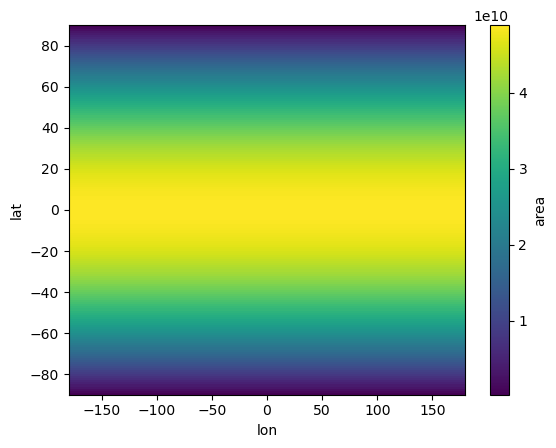

In [34]:
area_regridded_dataarray.mean(dim='model').plot()

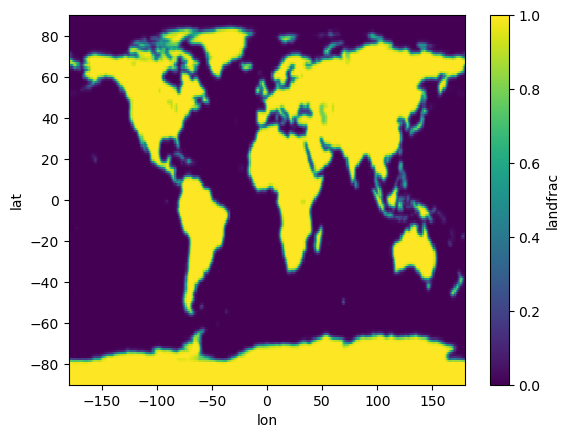

In [35]:
# weird strip in antarctica
landfrac_regridded_dataarray[0:5,:,:] = 1.

landfrac_regridded_dataarray.mean(dim='model').plot()


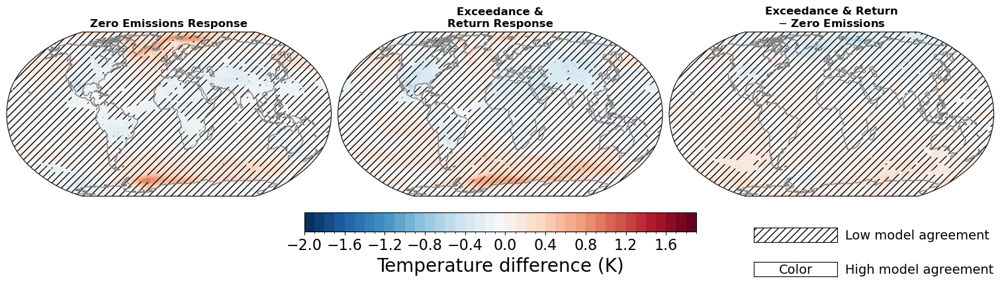

In [36]:
fig, axs = plt.subplots(1,3, figsize=(15, 5),
                            subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                       constrained_layout=True)

min_sign_agreement = 9

levels = np.arange(40.)/10.-2.
#levels = np.arange(30.)/10.-1.5

sign_agreement_zec = (((tas_regridded_datarray.isel(exp=1)-tas_regridded_datarray.isel(exp=0)) > 0.).sum(dim='model') >= min_sign_agreement) + (((tas_regridded_datarray.isel(exp=1)-tas_regridded_datarray.isel(exp=0)) < 0.).sum(dim='model') >= min_sign_agreement)
sign_agreement_cdr = (((tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=0)) > 0.).sum(dim='model') >= min_sign_agreement) + (((tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=0)) < 0.).sum(dim='model') >= min_sign_agreement)
sign_agreement_cmz = (((tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=1)) > 0.).sum(dim='model') >= min_sign_agreement) + (((tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=1)) < 0.).sum(dim='model') >= min_sign_agreement)

p = (tas_regridded_datarray.mean(dim='model').isel(exp=1)-tas_regridded_datarray.mean(dim='model').isel(exp=0)).plot(ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False, levels=levels)
axs[0].add_feature(feature.COASTLINE, edgecolor='grey')

axs[0].contourf(
    sign_agreement_zec.lon, sign_agreement_zec.lat, 1.-sign_agreement_zec,
    transform=ccrs.PlateCarree(),
    colors='none',
    levels=[.5, 1.5],
    hatches=('///','///'))

axs[0].set_title('Zero Emissions Response', fontweight='bold')
    
p = (tas_regridded_datarray.mean(dim='model').isel(exp=2)-tas_regridded_datarray.mean(dim='model').isel(exp=0)).plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False, levels=levels)
axs[1].add_feature(feature.COASTLINE, edgecolor='grey')


axs[1].contourf(
    sign_agreement_zec.lon, sign_agreement_zec.lat, 1.-sign_agreement_cdr,
    transform=ccrs.PlateCarree(),
    colors='none',
    levels=[.5, 1.5],
    hatches=('///','///'))

axs[1].set_title('Exceedance &\nReturn Response', fontweight='bold')

p = (tas_regridded_datarray.mean(dim='model').isel(exp=2)-tas_regridded_datarray.mean(dim='model').isel(exp=1)).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False, levels=levels)
axs[2].add_feature(feature.COASTLINE, edgecolor='grey')

axs[2].contourf(
    sign_agreement_zec.lon, sign_agreement_zec.lat, 1.-sign_agreement_cmz,
    transform=ccrs.PlateCarree(),
    colors='none',
    levels=[.5, 1.5],
    hatches=('///','///'))

axs[2].set_title('Exceedance & Return\n$\minus$ Zero Emissions', fontweight='bold')

cbar = fig.colorbar(p, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.08, pad=0.06, label='Temperature difference (K)')
cbar.ax.tick_params(labelsize=16) # Large font for tick labels
cbar.set_label('Temperature difference (K)', fontsize=20) # Large font for the label


ax6 = fig.add_subplot(22,10,200)
ax6.contourf([0,1,2],[0,1,2],np.ones((3,3))*1.,levels=[0.5,2],
             colors='none',
             hatches=['///'], 
             alpha=0.00)
ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
ax6.text(2.2,0.9,'Low model agreement', verticalalignment='center', fontsize=14)

ax7 = fig.add_subplot(22,10,220)
ax7.contourf([0,1,2],[0,1,2],np.ones((3,3))*0.,levels=[0.5,2],
             colors='none',
             hatches=['///'], 
             alpha=0.00)
ax7.xaxis.set_visible(False)
ax7.yaxis.set_visible(False)
ax7.text(2.2,0.9,'High model agreement', verticalalignment='center', fontsize=14)
ax7.text(1,0.9,'Color', verticalalignment='center', horizontalalignment='center', fontsize=14)


plt.savefig('fig_temp_response_maps_ensemblemean.png', dpi=300, bbox_inches='tight')


/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_2568/3197093396.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


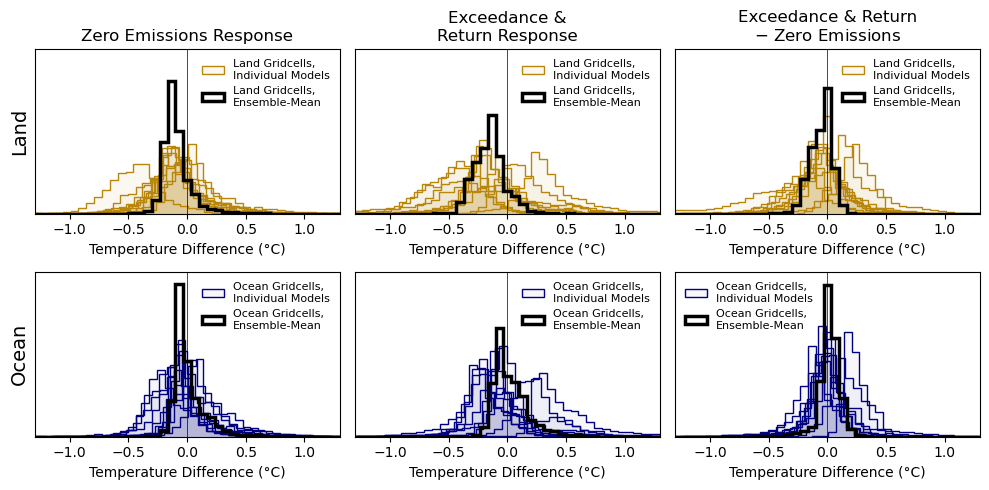

In [37]:
fig, axs_array = plt.subplots(2, 3, figsize=(10, 5),
                       constrained_layout=True)

axs = axs_array.flatten()

landmask_threshold = 0.1

landface = mcolors.to_rgba(landcolor, alpha=0.05)
oceanface = mcolors.to_rgba(oceancolor, alpha=0.03)

for model_i, model in enumerate(models_list):
    if model_i == 0:
        label_land = 'Land Gridcells,\nIndividual Models'
        label_ocean = 'Ocean Gridcells,\nIndividual Models'
    else:
        label_land = None
        label_ocean = None     
    #
    bin_edges = np.linspace(-10.,10.,300) + random.uniform(-0.1, 0.1)
    #
    # define land mask
    landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
    #
    data = data_dict[model]
    x = (data[1]-data[0]).values.flatten()
    y = (data[2]-data[0]).values.flatten()
    #
    weights = areas_dict[model].values.flatten()
    #
    axs[0].hist(x[landmask], edgecolor=landcolor, histtype='step', density=True, bins=bin_edges, weights=weights[landmask], fill=True, facecolor=landface, label=label_land)
    #
    axs[1].hist(y[landmask], edgecolor=landcolor, histtype='step', density=True, bins=bin_edges, weights=weights[landmask], fill=True, facecolor=landface, label=label_land)
    #
    axs[2].hist((y-x)[landmask], edgecolor=landcolor, histtype='step', density=True, bins=bin_edges, weights=weights[landmask], fill=True, facecolor=landface, label=label_land)
    #
    axs[3].hist(x[~landmask], edgecolor=oceancolor, histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], fill=True, facecolor=oceanface, label=label_ocean)
    #
    axs[4].hist(y[~landmask], edgecolor=oceancolor, histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], fill=True, facecolor=oceanface, label=label_ocean)
    #
    axs[5].hist((y-x)[~landmask], edgecolor=oceancolor, histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], fill=True, facecolor=oceanface, label=label_ocean)
    #

## ensemble mean distributions
x = (tas_regridded_datarray.isel(exp=1)-tas_regridded_datarray.isel(exp=0)).mean(dim='model').values.flatten()
y = (tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=0)).mean(dim='model').values.flatten()
     
landmask = (landfrac_regridded_dataarray.mean(dim='model') > landmask_threshold).values.flatten()
weights = (area_regridded_dataarray.mean(dim='model')).values.flatten()

bin_edges = np.linspace(-10.,10.,300)
axs[0].hist(x[landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[landmask], linewidth=2.5, label = 'Land Gridcells,\nEnsemble-Mean')
axs[1].hist(y[landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[landmask], linewidth=2.5, label = 'Land Gridcells,\nEnsemble-Mean')
axs[2].hist((y-x)[landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[landmask], linewidth=2.5, label = 'Land Gridcells,\nEnsemble-Mean')

axs[3].hist(x[~landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], linewidth=2.5, label = 'Ocean Gridcells,\nEnsemble-Mean')
axs[4].hist(y[~landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], linewidth=2.5, label = 'Ocean Gridcells,\nEnsemble-Mean')
axs[5].hist((y-x)[~landmask], edgecolor='black', histtype='step', density=True, bins=bin_edges, weights=weights[~landmask], linewidth=2.5, label = 'Ocean Gridcells,\nEnsemble-Mean')

panel_labels = ['Zero Emissions Response','Exceedance &\nReturn Response','Exceedance & Return\n$\minus$ Zero Emissions']
for ax_x in range(len(axs)):
    axs[ax_x].vlines(0, ymin=0,ymax=1, transform=axs[ax_x].get_xaxis_transform(), color='black', linewidth=0.5)
    #
    axs[ax_x].set_xlim(-1.3,1.3)
    axs[ax_x].set_ylim(0,6.5)
    #
    axs[ax_x].set_xlabel('Temperature Difference (°C)')
    axs[ax_x].tick_params(axis='y', left=False, labelleft=False)
    #
    if ax_x < 3:
        axs[ax_x].set_title(panel_labels[ax_x])
    if ax_x == 0:
        axs[ax_x].set_ylabel('Land', fontsize=14)
    if ax_x == 3:
        axs[ax_x].set_ylabel('Ocean', fontsize=14)
    axs[ax_x].legend(fontsize=8, frameon=False)

    
plt.tight_layout()

plt.savefig('fig_temp_response_landocean_histograms.png', dpi=300, bbox_inches='tight')



In [38]:
land_mean_zec_responses = {}
land_mean_e_and_r_responses = {}
ocean_mean_zec_responses = {}
ocean_mean_e_and_r_responses = {}

for model_i, model in enumerate(models_list):
    # define land mask
    landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
    #
    data = data_dict[model]
    x = (data[1]-data[0]).values.flatten()
    y = (data[2]-data[0]).values.flatten()
    #
    weights = areas_dict[model].values.flatten()
    #
    land_mean_zec_responses[model] = (x * weights)[landmask].sum()/weights[landmask].sum()
    land_mean_e_and_r_responses[model] = (y * weights)[landmask].sum()/weights[landmask].sum()
    #
    ocean_mean_zec_responses[model] = (x * weights)[~landmask].sum()/weights[~landmask].sum()
    ocean_mean_e_and_r_responses[model] = (y * weights)[~landmask].sum()/weights[~landmask].sum()


In [39]:
land_mean_zec_responses_array = np.array(list(land_mean_zec_responses.values()))
land_mean_e_and_r_responses_array = np.array(list(land_mean_e_and_r_responses.values()))
ocean_mean_zec_responses_array = np.array(list(ocean_mean_zec_responses.values()))
ocean_mean_e_and_r_responses_array = np.array(list(ocean_mean_e_and_r_responses.values()))

print(land_mean_zec_responses_array.mean(), land_mean_zec_responses_array.std())
print(land_mean_e_and_r_responses_array.mean(), land_mean_e_and_r_responses_array.std())
print()
print(ocean_mean_zec_responses_array.mean(), ocean_mean_zec_responses_array.std())
print(ocean_mean_e_and_r_responses_array.mean(), ocean_mean_e_and_r_responses_array.std())

print()
print((land_mean_zec_responses_array - land_mean_e_and_r_responses_array).mean(), (land_mean_zec_responses_array - land_mean_e_and_r_responses_array).std())
print((ocean_mean_zec_responses_array - ocean_mean_e_and_r_responses_array).mean(), (ocean_mean_zec_responses_array - ocean_mean_e_and_r_responses_array).std())


-0.09246874 0.13999805
-0.14066622 0.26613364

0.0012728035 0.12662914
0.007909736 0.23483525

0.048197486 0.1845154
-0.0066369297 0.13921043


In [40]:
land_mean_zec_responses = {}
land_mean_e_and_r_responses = {}
ocean_mean_zec_responses = {}
ocean_mean_e_and_r_responses = {}

for model_i, model in enumerate(models_list):
    # define land mask
    landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
    #
    data = data_dict[model]
    x = (data[1]-data[0]).values.flatten()
    y = (data[2]-data[0]).values.flatten()
    #
    weights = areas_dict[model].values.flatten()
    #
    globalmean_x = (x * weights).sum() / weights.sum()
    globalmean_y = (y * weights).sum() / weights.sum()
    #
    x = x - globalmean_x
    y = y - globalmean_y
    #
    land_mean_zec_responses[model] = (x * weights)[landmask].sum()/weights[landmask].sum()
    land_mean_e_and_r_responses[model] = (y * weights)[landmask].sum()/weights[landmask].sum()
    #
    ocean_mean_zec_responses[model] = (x * weights)[~landmask].sum()/weights[~landmask].sum()
    ocean_mean_e_and_r_responses[model] = (y * weights)[~landmask].sum()/weights[~landmask].sum()


In [41]:
land_mean_zec_responses_array = np.array(list(land_mean_zec_responses.values()))
land_mean_e_and_r_responses_array = np.array(list(land_mean_e_and_r_responses.values()))
ocean_mean_zec_responses_array = np.array(list(ocean_mean_zec_responses.values()))
ocean_mean_e_and_r_responses_array = np.array(list(ocean_mean_e_and_r_responses.values()))

print(land_mean_zec_responses_array.mean(), land_mean_zec_responses_array.std())
print(land_mean_e_and_r_responses_array.mean(), land_mean_e_and_r_responses_array.std())
print()
print(ocean_mean_zec_responses_array.mean(), ocean_mean_zec_responses_array.std())
print(ocean_mean_e_and_r_responses_array.mean(), ocean_mean_e_and_r_responses_array.std())

print()
print((land_mean_zec_responses_array - land_mean_e_and_r_responses_array).mean(), (land_mean_zec_responses_array - land_mean_e_and_r_responses_array).std())
print((ocean_mean_zec_responses_array - ocean_mean_e_and_r_responses_array).mean(), (ocean_mean_zec_responses_array - ocean_mean_e_and_r_responses_array).std())


-0.06506281 0.079553016
-0.10213147 0.09902919

0.028678725 0.03626779
0.046444498 0.04721114

0.037068654 0.047280215
-0.017765764 0.023747459


In [42]:
print(weighted_median(x[landmask], weights[landmask]))
print(weighted_median(y[landmask], weights[landmask]))
print(weighted_median((y-x)[landmask], weights[landmask]))

print()

print(weighted_median(x[~landmask], weights[~landmask]))
print(weighted_median(y[~landmask], weights[~landmask]))
print(weighted_median((y-x)[~landmask], weights[~landmask]))


0.030461982
0.021458715
0.046203032

-0.02483587
-0.011683375
0.0322565


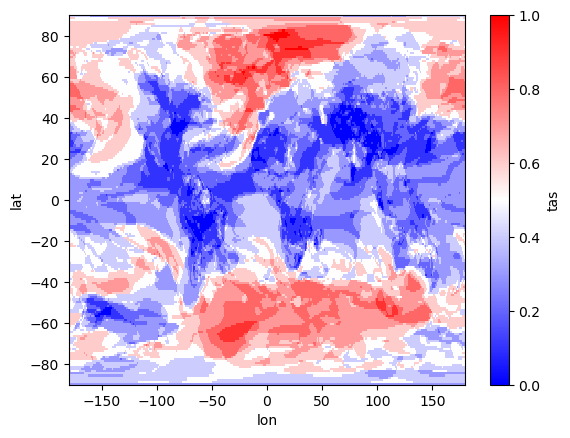

In [43]:
sign_agreement_zec =  (tas_regridded_datarray.isel(exp=1)-tas_regridded_datarray.isel(exp=0)) > 0.
(sign_agreement_zec.sum(dim='model')/10.).plot(cmap='bwr')


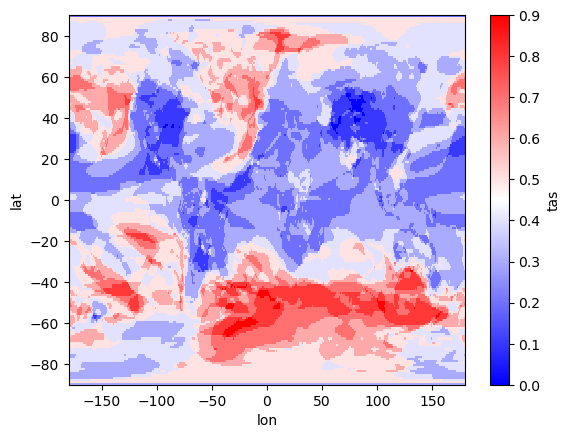

In [44]:
sign_agreement_cdr =  (tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=0)) > 0.
(sign_agreement_cdr.sum(dim='model')/10.).plot(cmap='bwr')

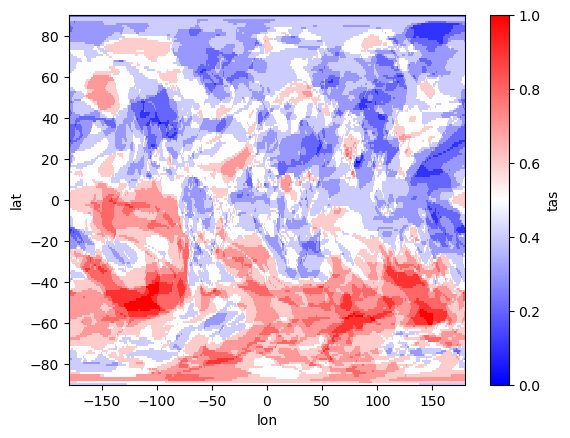

In [45]:
sign_agreement_cdrminuszec =  (tas_regridded_datarray.isel(exp=2)-tas_regridded_datarray.isel(exp=1)) > 0.
(sign_agreement_cdrminuszec.sum(dim='model')/10.).plot(cmap='bwr')

In [46]:
data_dict_ts = {'ACCESS-ESM1-5':ts_in_access,
'CESM2':ts_in_cesm,
'CNRM-ESM2-1':ts_in_cnrm,
'GFDL-ESM4':ts_in_gfdl,
'GISS_E2.1':ts_in_giss,
'HadCM3LC-Bris':ts_in_hadcm3lc3,
'MPI-ESM1-2-LR':ts_in_mpi,
'NorESM2-LM':ts_in_noresm,
'UKESM1.2':ts_in_ukesm,
'MIROC-ES2L':ts_in_miroc}

models_list_short = ['ACCESS-ESM1-5',
'CESM2',
'CNRM-ESM2-1',
'GFDL-ESM4',
'GISS_E2.1',
'HadCM3LC-Bris',
'MPI-ESM1-2-LR',
'NorESM2-LM',
'UKESM1.2',
'MIROC-ES2L']

nmodels_short = len(models_list_short)

tas_ts_datarray = xr.DataArray(
    np.zeros([300,3,nmodels_short])/np.zeros([300,3,nmodels_short]),
    coords={"time": np.arange(300), "exp": np.arange(3), "model": np.arange(nmodels_short)},
    dims=("time", "exp", "model"),
    name='tas',
    attrs=dict(
        description="Global Mean Surface Air Temperature",
        units="K",
    ))

for model_i, model in enumerate(models_list_short):
    tas_ts_datarray[0:len(data_dict_ts[model][0].isel(time=slice(0,300))),0,model_i] = data_dict_ts[model][0].isel(time=slice(0,300))
    tas_ts_datarray[100:,1,model_i] = data_dict_ts[model][1].isel(time=slice(0,200))
    tas_ts_datarray[100:,2,model_i] = data_dict_ts[model][2].isel(time=slice(0,200))


/var/folders/6g/x_x6jm6s1jq6fz2gmv70hhdh0000gp/T/ipykernel_2568/4023218564.py:26: RuntimeWarning: invalid value encountered in divide
  np.zeros([300,3,nmodels_short])/np.zeros([300,3,nmodels_short]),
HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 494 in H5O__attr_open_by_nam

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

In [76]:
tas_ts_datarray.to_netcdf('tas_globalmean_timeseries_flat10mip.nc')

In [48]:

#picontrols_dict['CESM2']
len(picontrols_dict['CESM2'].time)

500

In [49]:
regridded_picontrols_dict = {}
for model_i, model in enumerate(models_list_short):
    
    ntime = len(picontrols_dict[model].time)

    data = picontrols_dict[model]
    data['time'] = np.arange(ntime)
    #
    #need to add cyclic point before regridding
    wrap_data, wrap_lons = add_cyclic_point(data, coord=data.lon.as_numpy())
    #
    wrap_dataarray = xr.DataArray(wrap_data, 
        coords={ "time":data.time, "lat": data.lat, "lon": wrap_lons},
        dims=( "time", "lat", "lon"),
        name='tas')
    #
    regridder = xe.Regridder(wrap_dataarray.to_dataset(), ds_out, 'bilinear') # Or 'conservative', 'nearest_s2d', etc. [2, 9]
    ds_regridded = regridder(wrap_dataarray.to_dataset(), keep_attrs=True) # keep_attrs preserves metadata [4, 5]
    #picontrol_tas_regridded_datarray[:,:,j,model_i] = ds_regridded.to_array().squeeze()
    print(ds_regridded)
    #
    regridded_picontrols_dict[model] = ds_regridded['tas']


HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

<xarray.Dataset>
Dimensions:  (time: 500, y: 180, x: 360)
Coordinates:
  * time     (time) int64 0 1 2 3 4 5 6 7 8 ... 492 493 494 495 496 497 498 499
    lat      (y, x) float64 -89.5 -89.5 -89.5 -89.5 ... 89.5 89.5 89.5 89.5
    lon      (y, x) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Dimensions without coordinates: y, x
Data variables:
    tas      (time, y, x) float64 223.9 223.9 223.9 223.9 ... 252.8 252.8 252.8
Attributes:
    regrid_method:  bilinear


HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

...

<xarray.Dataset>
Dimensions:  (time: 500, y: 180, x: 360)
Coordinates:
  * time     (time) int64 0 1 2 3 4 5 6 7 8 ... 492 493 494 495 496 497 498 499
    lat      (y, x) float64 -89.5 -89.5 -89.5 -89.5 ... 89.5 89.5 89.5 89.5
    lon      (y, x) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Dimensions without coordinates: y, x
Data variables:
    tas      (time, y, x) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    regrid_method:  bilinear


HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

<xarray.Dataset>
Dimensions:  (time: 500, y: 180, x: 360)
Coordinates:
  * time     (time) int64 0 1 2 3 4 5 6 7 8 ... 492 493 494 495 496 497 498 499
    lat      (y, x) float64 -89.5 -89.5 -89.5 -89.5 ... 89.5 89.5 89.5 89.5
    lon      (y, x) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Dimensions without coordinates: y, x
Data variables:
    tas      (time, y, x) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    regrid_method:  bilinear


In [50]:
regridded_picontrols_dict

{'ACCESS-ESM1-5': <xarray.DataArray 'tas' (time: 500, y: 180, x: 360)>
 array([[[223.85471677, 223.86202056, 223.87190895, ..., 223.83912689,
          223.8433877 , 223.84850518],
         [227.39804627, 227.43812528, 227.48463205, ..., 227.29458344,
          227.32597898, 227.36065859],
         [234.75289391, 234.88076988, 235.01338432, ..., 234.39119904,
          234.50647463, 234.62811442],
         ...,
         [252.81658399, 252.8130342 , 252.80957993, ..., 252.82635606,
          252.82292702, 252.81988181],
         [253.13559524, 253.13180576, 253.12814258, ..., 253.14788656,
          253.14362468, 253.13953518],
         [253.01351992, 253.01197377, 253.01049836, ..., 253.01869388,
          253.01689447, 253.01516032]],
 
        [[226.22396128, 226.23087489, 226.24047302, ..., 226.21265103,
          226.21498889, 226.21866541],
         [229.2822521 , 229.32011209, 229.36451345, ..., 229.19039832,
          229.21689104, 229.24783983],
         [236.44707068, 236.5678

In [51]:
#n_samples = 1000
#rng = np.random.default_rng()
#sampling_length = averaging_length
#quantile_to_use = .05

pictrl_ensmean_tas_regridded_datarray_1 = xr.DataArray(
    np.zeros([n_samples,nmodels,180,360]),
    coords={"ens":np.arange(n_samples), "model": np.arange(nmodels), "lat": np.arange(180)-89.5, "lon": np.arange(360)-179.5},
    dims=("ens", "model", "lat", "lon"),
    name='tas',
    attrs=dict(
        description="Surface Air Temperature",
        units="K",
    ))

pictrl_ensmean_tas_regridded_datarray_2 = xr.DataArray(
    np.zeros([n_samples,nmodels,180,360]),
    coords={"ens":np.arange(n_samples), "model": np.arange(nmodels), "lat": np.arange(180)-89.5, "lon": np.arange(360)-179.5},
    dims=("ens", "model", "lat", "lon"),
    name='tas',
    attrs=dict(
        description="Surface Air Temperature",
        units="K",
    ))

for model_i, model in enumerate(models_list):
    n_startingyears = len(regridded_picontrols_dict[model].time) - sampling_length
    starting_indices_1 = rng.integers(low=0, high=n_startingyears, size=n_samples*2)  
    starting_indices_2 = rng.integers(low=0, high=n_startingyears, size=n_samples*2)  
    i_sample = 0
    i_counter = 0
    while i_sample < n_samples:
        if i_sample%200 == 0:
            print(model + ': '+str(i_sample))
        a = starting_indices_1[i_counter]
        b = starting_indices_2[i_counter]
        if abs(a - b) > sampling_length:
            pictrl_ensmean_tas_regridded_datarray_1[i_sample,model_i,:,:] = regridded_picontrols_dict[model].isel(time=slice(a,a+sampling_length)).mean(dim='time')/float(nmodels)
            pictrl_ensmean_tas_regridded_datarray_2[i_sample,model_i,:,:] = regridded_picontrols_dict[model].isel(time=slice(b,b+sampling_length)).mean(dim='time')/float(nmodels)
            i_sample = i_sample+1
        i_counter = i_counter + 1

    

ACCESS-ESM1-5: 0
ACCESS-ESM1-5: 200
ACCESS-ESM1-5: 200
ACCESS-ESM1-5: 400
ACCESS-ESM1-5: 600
ACCESS-ESM1-5: 800
CESM2: 0
CESM2: 200
CESM2: 200
CESM2: 400
CESM2: 600
CESM2: 800
CESM2: 800
CNRM-ESM2-1: 0
CNRM-ESM2-1: 200
CNRM-ESM2-1: 400
CNRM-ESM2-1: 600
CNRM-ESM2-1: 800
GFDL-ESM4: 0
GFDL-ESM4: 0
GFDL-ESM4: 200
GFDL-ESM4: 400
GFDL-ESM4: 400
GFDL-ESM4: 600
GFDL-ESM4: 800
GISS_E2.1: 0
GISS_E2.1: 200
GISS_E2.1: 400
GISS_E2.1: 600
GISS_E2.1: 600
GISS_E2.1: 800
GISS_E2.1: 800
HadCM3LC-Bris: 0
HadCM3LC-Bris: 200
HadCM3LC-Bris: 400
HadCM3LC-Bris: 400
HadCM3LC-Bris: 400
HadCM3LC-Bris: 600
HadCM3LC-Bris: 800
MPI-ESM1-2-LR: 0
MPI-ESM1-2-LR: 200
MPI-ESM1-2-LR: 400
MPI-ESM1-2-LR: 600
MPI-ESM1-2-LR: 800
NorESM2-LM: 0
NorESM2-LM: 200
NorESM2-LM: 400
NorESM2-LM: 400
NorESM2-LM: 600
NorESM2-LM: 600
NorESM2-LM: 800
UKESM1.2: 0
UKESM1.2: 200
UKESM1.2: 400
UKESM1.2: 600
UKESM1.2: 800
UKESM1.2: 800
MIROC-ES2L: 0
MIROC-ES2L: 0
MIROC-ES2L: 200
MIROC-ES2L: 200
MIROC-ES2L: 400
MIROC-ES2L: 600
MIROC-ES2L: 800


In [52]:
ens_mean_pictrl_diff = pictrl_ensmean_tas_regridded_datarray_1.mean(dim="model") - pictrl_ensmean_tas_regridded_datarray_2.mean(dim="model")


In [66]:
landmask_regridded = (landfrac_regridded_dataarray.mean(dim='model') > landmask_threshold).values.flatten()
len(landmask_regridded)

weights_regridded = (area_regridded_dataarray.mean(dim='model')).values.flatten()



In [67]:
land_medians = np.zeros(n_samples)
ocean_medians = np.zeros(n_samples)
for i_ens in range(n_samples):
    land_medians[i_ens] = weighted_median(ens_mean_pictrl_diff.isel(ens=i_ens).values.flatten()[landmask_regridded], weights_regridded[landmask_regridded])
    ocean_medians[i_ens] = weighted_median(ens_mean_pictrl_diff.isel(ens=i_ens).values.flatten()[~landmask_regridded], weights_regridded[~landmask_regridded])
    

In [68]:
print(np.quantile(land_medians, .05))
print(np.quantile(land_medians, .95))
print(np.quantile(ocean_medians, .05))
print(np.quantile(ocean_medians, .95))


-0.004622565327297501
0.00492286700807849
-0.0030253210636068673
0.0030976622967374455


/Users/CDKoven/miniforge3/envs/xesmf/lib/python3.10/site-packages/dask/array/core.py:4915: RuntimeWarning: invalid value encountered in divide
  result = function(*args, **kwargs)
/Users/CDKoven/miniforge3/envs/xesmf/lib/python3.10/site-packages/dask/array/core.py:4915: RuntimeWarning: invalid value encountered in divide
  result = function(*args, **kwargs)
/Users/CDKoven/miniforge3/envs/xesmf/lib/python3.10/site-packages/dask/array/core.py:4915: RuntimeWarning: invalid value encountered in divide
  result = function(*args, **kwargs)
/Users/CDKoven/miniforge3/envs/xesmf/lib/python3.10/site-packages/dask/array/core.py:4915: RuntimeWarning: invalid value encountered in divide
  result = function(*args, **kwargs)


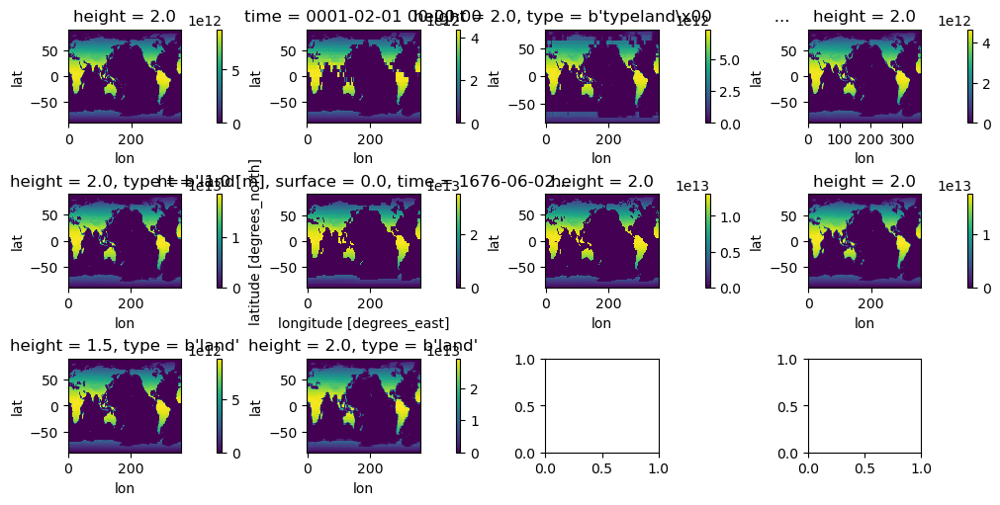

In [69]:
pictrl_lnd_minus_ocn_temp_dict = {}

fig, axs_array = plt.subplots(3, 4, figsize=(10, 5),
                       constrained_layout=True)

axs = axs_array.flatten()

for model_i, model in enumerate(models_list_short):
    pictrl_meantemp = picontrols_dict[model].mean(dim='time')
    landfrac = (landmasks_dict[model]/landmasks_dict[model].max()).fillna(0.)
    areas = areas_dict[model]
    #if model == 'HadCM3LC-Bris': # model == 'UKESM1.2' or 
        #landfrac = landfrac.rename({'latitude': 'lat', 'longitude':'lon'})
        #areas = areas.rename({'latitude': 'lat', 'longitude':'lon'})
    landfrac['lat'] = pictrl_meantemp['lat'].data
    landfrac['lon'] = pictrl_meantemp['lon'].data
    areas['lat'] = areas['lat'].data
    areas['lon'] = areas['lon'].data
    #
    (pictrl_meantemp * landfrac * areas).plot(ax=axs[model_i])
    #
    pictrl_lnd_minus_ocn_temp_dict[model] = ((pictrl_meantemp * landfrac * area).sum(dim=['lat','lon']) / (landfrac * area).sum(dim=['lat','lon']) - (pictrl_meantemp * (1.-landfrac) * area).sum(dim=['lat','lon']) / ((1.-landfrac) * area).sum(dim=['lat','lon'])).values
    #
    #pictrl_meantemp = picontrols_dict[model].mean(dim='time').values.flatten()
    #landmask = (landmasks_dict[model] > landmask_threshold * landmasks_dict[model].max()).values.flatten()
    #areas = areas_dict[model].values.flatten()
    ##
    #pictrl_lnd_minus_ocn_temp_dict[model] = (pictrl_meantemp * areas)[landmask].sum() / areas[landmask].sum() - (pictrl_meantemp * areas)[~landmask].sum() / areas[~landmask].sum()


In [70]:
pictrl_lnd_minus_ocn_temp_dict

{'ACCESS-ESM1-5': array(-7.79716993),
 'CESM2': array(-31.35469184),
 'CNRM-ESM2-1': array(nan),
 'GFDL-ESM4': array(-8.96402376),
 'GISS_E2.1': array(-7.86682582),
 'HadCM3LC-Bris': array(-8.96155923),
 'MPI-ESM1-2-LR': array(nan),
 'NorESM2-LM': array(-29.22874742),
 'UKESM1.2': array(nan),
 'MIROC-ES2L': array(nan)}

In [71]:
import scipy
def savgol_filter(array, window, order=2):
        smooth_array = array.copy()
        smooth_array[:] = scipy.signal.savgol_filter(array, window, order)
        return(smooth_array)

(0.0, 1.0, 0.0, 1.0)

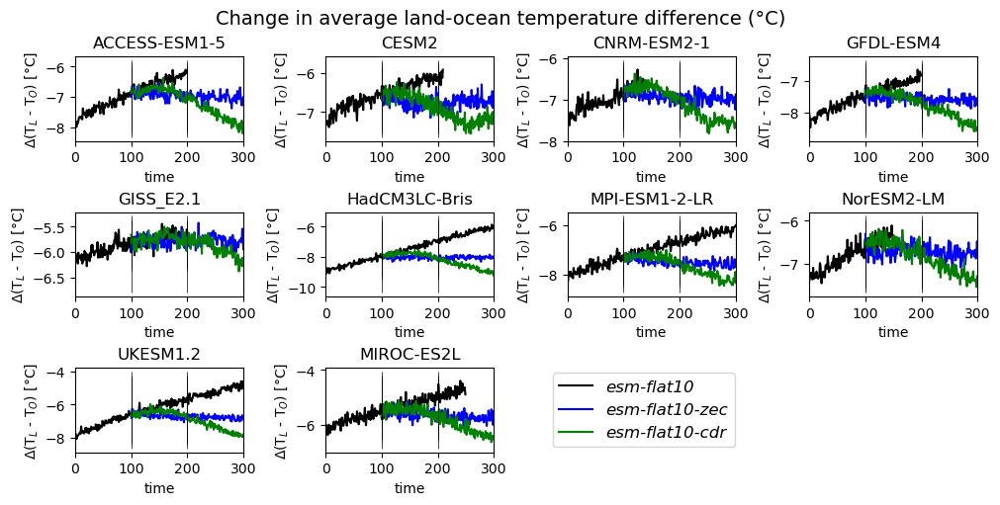

In [72]:
colorlist = {'flat10':'black','flat10-zec':'blue','flat10-cdr':'green'}

fig, axs_array = plt.subplots(3, 4, figsize=(10, 5),
                       constrained_layout=True)

axs = axs_array.flatten()

for model_i, model in enumerate(models_list_short):
    if model_i == 9:
        annotations = ['esm-flat10','esm-flat10-zec','esm-flat10-cdr']
    else:
        annotations = [None,None,None]
    for exp_i, exp in enumerate(exp_list):
        if exp == 'flat10':
            landsea_tempdiffs_dict[model][exp]['time'] = np.arange(len(landsea_tempdiffs_dict[model][exp].time))
        else:
            landsea_tempdiffs_dict[model][exp]['time'] = np.arange(len(landsea_tempdiffs_dict[model][exp].time)) + 100.
        #(landsea_tempdiffs_dict[model][exp] - pictrl_lnd_minus_ocn_temp_dict[model]).plot(color=colorlist[exp], ax=axs[model_i])
        #(savgol_filter(landsea_tempdiffs_dict[model][exp], 15) - landsea_tempdiffs_dict[model]['flat10'].isel(time=slice(0,20)).mean(dim='time')).plot(color=colorlist[exp], ax=axs[model_i], label=annotations[exp_i])
        ((landsea_tempdiffs_dict[model][exp]) ).plot(color=colorlist[exp], ax=axs[model_i], label=annotations[exp_i])
        axs[model_i].set_title(model)
        ymin, ymax = axs[model_i].get_ylim()
        axs[model_i].vlines((100.,200.), ymin=ymin,ymax=ymax, color='black', linewidth=0.5)
        axs[model_i].set_xlim(0., 300.)
        #axs[model_i].set_ylim(-0.1, 1.6)
        axs[model_i].set_ylabel('$\Delta$(T$_L$ - T$_O$) [°C]')
        if model_i == 9:
            legend = axs[model_i].legend(loc='center left', bbox_to_anchor=(1.3, 0.5), prop={'style': 'italic', 'size': 12})
            legend.set_in_layout(False)


fig.suptitle('Change in average land-ocean temperature difference (°C)', fontsize=14)

axs[10].axis('off')
axs[11].axis('off')

In [74]:
from scipy import stats

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

saving values for flat10 regression


HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

...

Regress. coeffs for NorESM2-LM in flat10-zec are different from flat10: False


HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

  #005: H5Oattribute.c line 494 in H5O__attr_open_by_name(): can't locate attribute: '_QuantizeGranularBitRoundNumberOfSignificantDigits'
    major: Attribute
    minor: Object not found
HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 494 in H5O__attr_open_by_name(): can't loc

HDF5-DIAG: Error detected in HDF5 (1.12.2) MPI-process 0:
  #000: H5A.c line 528 in H5Aopen_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #001: H5VLcallback.c line 1091 in H5VL_attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #002: H5VLcallback.c line 1058 in H5VL__attr_open(): attribute open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLnative_attr.c line 130 in H5VL__native_attr_open(): can't open attribute
    major: Attribute
    minor: Can't open object
  #004: H5Aint.c line 545 in H5A__open_by_name(): unable to load attribute info from object header
    major: Attribute
    minor: Unable to initialize object
  #005: H5Oattribute.c line 476 in H5O__attr_open_by_name(): can't open attribute
    major: Attribute
    minor: Can't open object
  #006: H5Adense.c line 394 in H5A__dense_open(): can't locate attribute in name index
    major: Attribute
    minor: Object

Regress. coeffs for NorESM2-LM in flat10-cdr are different from flat10: True
saving values for flat10 regression
Regress. coeffs for UKESM1.2 in flat10-zec are different from flat10: True
Regress. coeffs for UKESM1.2 in flat10-cdr are different from flat10: True
saving values for flat10 regression
Regress. coeffs for MIROC-ES2L in flat10-zec are different from flat10: True
Regress. coeffs for MIROC-ES2L in flat10-cdr are different from flat10: True


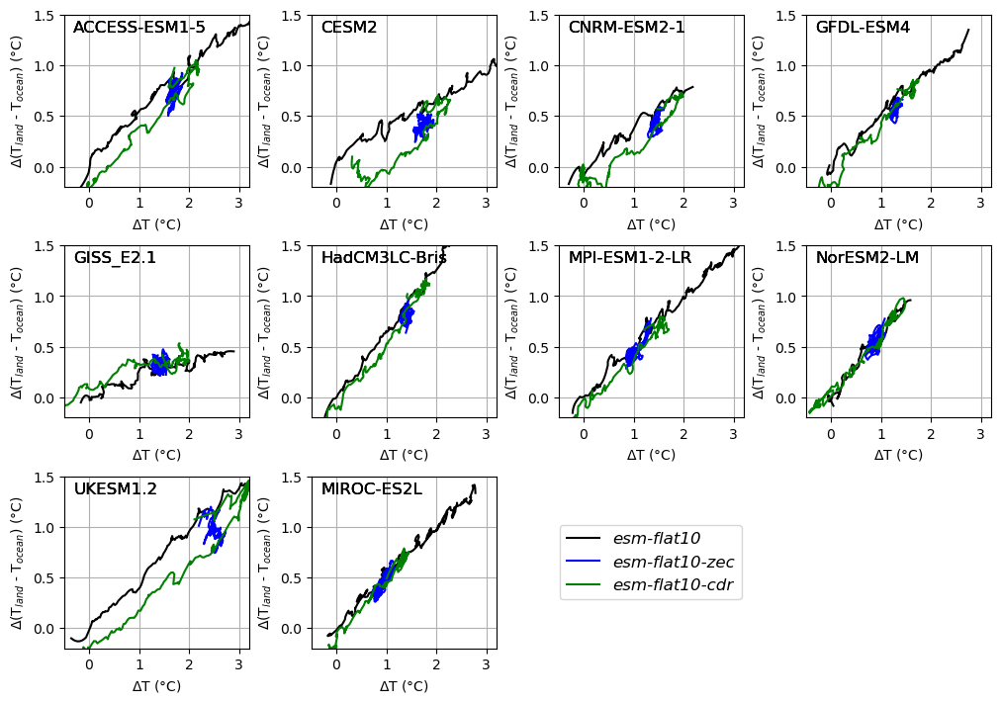

In [75]:
colorlist = {'flat10':'black','flat10-zec':'blue','flat10-cdr':'green'}

fig, axs_array = plt.subplots(3, 4, figsize=(10, 7),
                       constrained_layout=True)

axs = axs_array.flatten()

for model_i, model in enumerate(models_list_short):
    if model_i == 9:
        annotations = ['esm-flat10','esm-flat10-zec','esm-flat10-cdr']
    else:
        annotations = [None,None,None]
    for exp_i, exp in enumerate(exp_list):

        y = (landsea_tempdiffs_dict[model][exp] - landsea_tempdiffs_dict[model]['flat10'].isel(time=slice(0,20)).mean(dim='time'))
        x = data_dict_ts[model][exp_i] - data_dict_ts[model][0].isel(time=slice(0,20)).mean(dim='time')
        
        if exp_i == 0:
            x_flat10 = x
            y_flat10 = y
            print('saving values for flat10 regression')
        else:
            ### we want to pool results with flat10 numbers to ask whether the flat10zec or flat10cdr regressions 
            ### are significantly different from the flat10 regressions
            # Combine into a single DataFrame with a group indicator
            df1 = pd.DataFrame({'x': x_flat10, 'y': y_flat10, 'group': 0})
            df2 = pd.DataFrame({'x': x, 'y': y, 'group': 1})
            df_total = pd.concat([df1, df2], ignore_index=True)

            # Fit an interaction model
            # The term 'x:group' explicitly captures the difference in slopes
            statmodel = smf.ols("y ~ x + group + x:group", data=df_total).fit()
            #print(model.summary())
            
            # Test if the interaction effect (difference in slopes) is strictly 0
            #hypotheses = "x:group = 0"
            #t_test_result_slope = model.t_test(hypotheses)
            #print(t_test_result_slope)

            # Jointly test if both difference terms are zero
            hypotheses = "(group = 0), (x:group = 0)"
            f_test_result = statmodel.f_test(hypotheses)
            print('Regress. coeffs for '+model+' in '+exp_list[exp_i]+' are different from flat10: '+str(f_test_result.pvalue < 0.05))
            
        landsea_tempdiff = savgol_filter(y, 15)
        gmst_change = savgol_filter(x, 15)
        axs[model_i].plot(gmst_change, landsea_tempdiff, color=colorlist[exp], label=annotations[exp_i])
        #axs[model_i].set_title(model)
        ymin, ymax = axs[model_i].get_ylim()
        #axs[model_i].vlines((100.,200.), ymin=ymin,ymax=ymax, color='black', linewidth=0.5)
        axs[model_i].set_xlim(-0.5,3.2)
        axs[model_i].set_ylim(-0.2, 1.5)
        axs[model_i].set_ylabel('$\Delta$(T$_{land}$ - T$_{ocean}$) (°C)')
        axs[model_i].set_xlabel('$\Delta$T (°C)')
        axs[model_i].annotate(model, xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12)
        axs[model_i].grid()
        if model_i == 9:
            legend = axs[model_i].legend(loc='center left', bbox_to_anchor=(1.3, 0.5), prop={'style': 'italic', 'size': 12})
            legend.set_in_layout(False)


#fig.suptitle('Change in mean land-ocean temperature difference versus change in global mean temperature', fontsize=14)

axs[10].axis('off')
axs[11].axis('off')

plt.savefig('fig_deltaT_vs_delta_Tland_minus_Tocean.png', dpi=300, bbox_inches='tight')
